# Economics Real-Data Results / Economics 真实数据结果

This notebook consolidates the formal economics real-data suite: CMDL, plain-LSTM baseline, and the three core ablation variants.
本 notebook 汇总 economics 真实数据正式实验：CMDL、plain-LSTM baseline，以及三个核心 ablation 变体。

## Sections / 结构

- Setup: repo paths, imports, and the single configuration cell.
- Optional direct-run: programmatic training hooks for CMDL, baseline, and ablation.
- Unified comparison: build normalized run-level tables for forecasting and lag/proxy diagnostics.
- Multi-seed summaries and plots: aggregate seeds 0/1/2 and export figures.
- Prediction snapshots: compare canonical runs on a few entities.

## Defaults / 默认行为

- The active plan is `formal_target`.
- Direct-run switches are opt-in and default to `False`.
- The notebook reads from `data/economics/processed/economics_cleaned_long.csv`.
- Outputs are organized under `outputs/notebook_economics/<plan>/...`.

In [ ]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

current = Path.cwd().resolve()
repo_root = next(
    (
        path
        for path in [current, *current.parents]
        if (path / "config").exists() and (path / "data").exists() and (path / "experiments").exists()
    ),
    None,
)

if repo_root is None:
    raise RuntimeError(f"Could not find repo root from {current}")

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

print(f"repo_root = {repo_root}")

repo_root = C:\DevSpace\PyDevspace\CMDL


In [14]:
from argparse import Namespace
import importlib

from evaluation import economics_comparison as economics_comparison_module
from experiments import run_economics as run_economics_module
from experiments import run_economics_ablation as run_economics_ablation_module
from experiments import run_economics_lstm_baseline as run_economics_lstm_baseline_module

economics_comparison_module = importlib.reload(economics_comparison_module)
run_economics_module = importlib.reload(run_economics_module)
run_economics_ablation_module = importlib.reload(run_economics_ablation_module)
run_economics_lstm_baseline_module = importlib.reload(run_economics_lstm_baseline_module)

build_economics_comparison = economics_comparison_module.build_economics_comparison
build_task_table = economics_comparison_module.build_task_table
build_interpretability_table = economics_comparison_module.build_interpretability_table
run_cmdl_experiment = run_economics_module.run_experiment
run_baseline_experiment = run_economics_lstm_baseline_module.run_experiment
run_ablation_suite = run_economics_ablation_module.run_suite

PRESET_CONFIGS = {
    "quick_check": {"epochs": 3, "patience": 1, "log_every": 1},
    "notebook_medium": {"epochs": 30, "patience": 8, "log_every": 5},
    "formal_target": {"epochs": 120, "patience": 20, "log_every": 10},
}

ACTIVE_PLAN = "formal_target"
SEEDS = [0, 1, 2]
CANONICAL_SEED = SEEDS[0]
RUN_CMDL = False
RUN_BASELINE = False
RUN_ABLATIONS = False
DISABLE_MLFLOW = False
TARGET_COLUMN = "ctfp"

DATA_PATH = repo_root / "data" / "economics" / "processed" / "economics_cleaned_long.csv"
OUTPUT_ROOT = repo_root / "outputs" / "notebook_economics" / ACTIVE_PLAN
CMDL_OUTPUT_DIR = OUTPUT_ROOT / "cmdl"
BASELINE_OUTPUT_DIR = OUTPUT_ROOT / "plain_lstm"
ABLATION_OUTPUT_DIR = OUTPUT_ROOT / "ablation"
COMPARISON_DIR = OUTPUT_ROOT / "comparison"
PLOTS_DIR = OUTPUT_ROOT / "comparison_plots"

for path in [OUTPUT_ROOT, CMDL_OUTPUT_DIR, BASELINE_OUTPUT_DIR, ABLATION_OUTPUT_DIR, COMPARISON_DIR, PLOTS_DIR]:
    path.mkdir(parents=True, exist_ok=True)

COMMON_ARGS = {
    "csv_path": str(DATA_PATH),
    "year_start": 1980,
    "year_end": 2023,
    "train_end_year": 2007,
    "val_end_year": 2013,
    "target_column": TARGET_COLUMN,
    "max_missing_share": 0.15,
    "lr": 1e-3,
    "lambda_r": 0.1,
    "temperature": 1.0,
    "lag_bias_strength": 1.0,
    "grad_clip": 1.0,
    "device": "auto",
    "disable_mlflow": DISABLE_MLFLOW,
}

plan_table = pd.DataFrame.from_dict(PRESET_CONFIGS, orient="index")
notebook_switches = pd.DataFrame(
    {
        "value": [
            ACTIVE_PLAN,
            DATA_PATH,
            CMDL_OUTPUT_DIR,
            BASELINE_OUTPUT_DIR,
            ABLATION_OUTPUT_DIR,
            COMPARISON_DIR,
            PLOTS_DIR,
            ", ".join(str(seed) for seed in SEEDS),
            CANONICAL_SEED,
            RUN_CMDL,
            RUN_BASELINE,
            RUN_ABLATIONS,
            DISABLE_MLFLOW,
        ]
    },
    index=[
        "ACTIVE_PLAN",
        "DATA_PATH",
        "CMDL_OUTPUT_DIR",
        "BASELINE_OUTPUT_DIR",
        "ABLATION_OUTPUT_DIR",
        "COMPARISON_DIR",
        "PLOTS_DIR",
        "SEEDS",
        "CANONICAL_SEED",
        "RUN_CMDL",
        "RUN_BASELINE",
        "RUN_ABLATIONS",
        "DISABLE_MLFLOW",
    ],
)

display(plan_table)
display(pd.Series({**COMMON_ARGS, **PRESET_CONFIGS[ACTIVE_PLAN]}, name="value").to_frame())
display(notebook_switches)
print(f"ACTIVE_PLAN = {ACTIVE_PLAN}")
print(f"OUTPUT_ROOT = {OUTPUT_ROOT}")

,epochs,patience,log_every
quick_check,3,1,1
notebook_medium,30,8,5
formal_target,120,20,10


,value
csv_path,C:\DevSpace\PyDevspace\CMDL\data\economics\pro...
year_start,1980
year_end,2023
train_end_year,2007
val_end_year,2013
target_column,ctfp
max_missing_share,0.15
lr,0.001
lambda_r,0.1
temperature,1.0


,value
ACTIVE_PLAN,formal_target
DATA_PATH,C:\DevSpace\PyDevspace\CMDL\data\economics\pro...
CMDL_OUTPUT_DIR,C:\DevSpace\PyDevspace\CMDL\outputs\notebook_e...
BASELINE_OUTPUT_DIR,C:\DevSpace\PyDevspace\CMDL\outputs\notebook_e...
ABLATION_OUTPUT_DIR,C:\DevSpace\PyDevspace\CMDL\outputs\notebook_e...
COMPARISON_DIR,C:\DevSpace\PyDevspace\CMDL\outputs\notebook_e...
PLOTS_DIR,C:\DevSpace\PyDevspace\CMDL\outputs\notebook_e...
SEEDS,"0, 1, 2"
CANONICAL_SEED,0
RUN_CMDL,False


ACTIVE_PLAN = formal_target
OUTPUT_ROOT = C:\DevSpace\PyDevspace\CMDL\outputs\notebook_economics\formal_target


In [3]:
cmdl_summaries: list[dict[str, object]] = []
baseline_summaries: list[dict[str, object]] = []
ablation_summary_frame = pd.DataFrame()
ablation_aggregated_frame = pd.DataFrame()

if RUN_CMDL:
    for seed in SEEDS:
        cmdl_args = Namespace(
            **COMMON_ARGS,
            **PRESET_CONFIGS[ACTIVE_PLAN],
            seed=seed,
            output_dir=str(CMDL_OUTPUT_DIR),
            experiment_name=f"E4_economics_cmdl_seed{seed}",
            smoke=ACTIVE_PLAN == "quick_check",
        )
        cmdl_summary = run_cmdl_experiment(cmdl_args)
        cmdl_summaries.append(cmdl_summary)
        print(
            f"CMDL seed={seed} test_r2={cmdl_summary['metrics']['test']['r2']:.4f} "
            f"test_mae={cmdl_summary['metrics']['test']['mae']:.4f}"
        )
else:
    print("RUN_CMDL = False; skipping direct CMDL training.")

if RUN_BASELINE:
    for seed in SEEDS:
        baseline_args = Namespace(
            **COMMON_ARGS,
            **PRESET_CONFIGS[ACTIVE_PLAN],
            seed=seed,
            output_dir=str(BASELINE_OUTPUT_DIR),
            experiment_name=f"E4_economics_lstm_seed{seed}",
            smoke=ACTIVE_PLAN == "quick_check",
        )
        baseline_summary = run_baseline_experiment(baseline_args)
        baseline_summaries.append(baseline_summary)
        print(
            f"Baseline seed={seed} test_r2={baseline_summary['metrics']['test']['r2']:.4f} "
            f"test_mae={baseline_summary['metrics']['test']['mae']:.4f}"
        )
else:
    print("RUN_BASELINE = False; skipping direct baseline training.")

if RUN_ABLATIONS:
    ablation_args = Namespace(
        **COMMON_ARGS,
        **PRESET_CONFIGS[ACTIVE_PLAN],
        variant="all",
        seeds=SEEDS,
        output_dir=str(ABLATION_OUTPUT_DIR),
        experiment_prefix="E4_economics_ablation",
        smoke=ACTIVE_PLAN == "quick_check",
    )
    ablation_summary_frame, ablation_aggregated_frame = run_ablation_suite(ablation_args)
    display(ablation_summary_frame)
    if not ablation_aggregated_frame.empty:
        display(ablation_aggregated_frame)
else:
    print("RUN_ABLATIONS = False; skipping direct ablation training.")

RUN_CMDL = False; skipping direct CMDL training.
RUN_BASELINE = False; skipping direct baseline training.
RUN_ABLATIONS = False; skipping direct ablation training.


In [15]:
comparison = build_economics_comparison(
    cmdl_root=CMDL_OUTPUT_DIR,
    baseline_root=BASELINE_OUTPUT_DIR,
    ablation_root=ABLATION_OUTPUT_DIR,
)
task_table = build_task_table(comparison)
interpretability_table = build_interpretability_table(comparison)

comparison_path = COMPARISON_DIR / "economics_comparison.csv"
task_table_path = COMPARISON_DIR / "forecast_comparison.csv"
interpretability_path = COMPARISON_DIR / "lag_proxy_diagnostics.csv"

comparison.to_csv(comparison_path, index=False)
task_table.to_csv(task_table_path, index=False)
interpretability_table.to_csv(interpretability_path, index=False)

print(f"comparison rows = {len(comparison)}")
print(f"task table path = {task_table_path}")
print(f"interpretability path = {interpretability_path}")
display(task_table)
display(interpretability_table)

comparison rows = 15
task table path = C:\DevSpace\PyDevspace\CMDL\outputs\notebook_economics\formal_target\comparison\forecast_comparison.csv
interpretability path = C:\DevSpace\PyDevspace\CMDL\outputs\notebook_economics\formal_target\comparison\lag_proxy_diagnostics.csv


,display_name,family,variant,seed,experiment,target_column,best_epoch,best_val_task_loss,test_r2,test_mae,test_mse
0,Uniform Lag,ablation,uniform_lag,0,E4_economics_ablation_uniform_lag_seed0,ctfp,1,2.837034,-0.045594,1.571959,4.335729
1,No Recon Regularization,ablation,no_recon_regularization,0,E4_economics_ablation_no_recon_regularization_...,ctfp,5,2.768782,-0.057988,1.567320,4.385006
2,No AC Encoder,ablation,no_ac_encoder,0,E4_economics_ablation_no_ac_encoder_seed0,ctfp,5,2.771364,-0.058632,1.567689,4.387622
3,CMDL,cmdl,None,1,E4_economics_cmdl_seed1,ctfp,1,3.029675,-0.060747,1.580845,4.398145
4,CMDL,cmdl,None,2,E4_economics_cmdl_seed2,ctfp,2,2.893610,-0.069764,1.597144,4.435274
5,Plain LSTM,plain_lstm,None,2,E4_economics_lstm_seed2,ctfp,9,2.859536,-0.074768,1.600236,4.455986
6,Uniform Lag,ablation,uniform_lag,2,E4_economics_ablation_uniform_lag_seed2,ctfp,26,2.984248,-0.080240,1.613011,4.469770
7,Plain LSTM,plain_lstm,None,1,E4_economics_lstm_seed1,ctfp,1,2.853610,-0.087521,1.619266,4.510215
8,No AC Encoder,ablation,no_ac_encoder,2,E4_economics_ablation_no_ac_encoder_seed2,ctfp,23,2.963230,-0.090137,1.620773,4.515943
9,No Recon Regularization,ablation,no_recon_regularization,2,E4_economics_ablation_no_recon_regularization_...,ctfp,8,2.959364,-0.104116,1.625369,4.578959


,display_name,family,variant,seed,experiment,target_column,lag_method,test_effective_kstar_proxy_spearman_rho,test_effective_kstar_mean,test_effective_kstar_std,test_effective_lag_entropy_mean,test_proxy_signal_r2
0,No Recon Regularization,ablation,no_recon_regularization,1,E4_economics_ablation_no_recon_regularization_...,ctfp,learned_omega,1.000000,3.926327,0.303777,1.820895,9.365884e-01
1,Plain LSTM,plain_lstm,None,1,E4_economics_lstm_seed1,ctfp,lag_occlusion,0.191716,5.406623,0.982570,2.199584,NaN
2,Plain LSTM,plain_lstm,None,0,E4_economics_lstm_seed0,ctfp,lag_occlusion,0.002569,5.400273,1.248111,2.146421,NaN
3,Uniform Lag,ablation,uniform_lag,1,E4_economics_ablation_uniform_lag_seed1,ctfp,learned_omega,0.000000,5.500000,0.000000,2.302585,9.376696e-01
4,Uniform Lag,ablation,uniform_lag,0,E4_economics_ablation_uniform_lag_seed0,ctfp,learned_omega,0.000000,5.500000,0.000000,2.302585,9.176309e-01
5,Uniform Lag,ablation,uniform_lag,2,E4_economics_ablation_uniform_lag_seed2,ctfp,learned_omega,0.000000,5.500000,0.000000,2.302585,8.197623e-01
6,No AC Encoder,ablation,no_ac_encoder,1,E4_economics_ablation_no_ac_encoder_seed1,ctfp,learned_omega,0.000000,3.745347,0.000000,1.798404,-2.295863e+15
7,No AC Encoder,ablation,no_ac_encoder,2,E4_economics_ablation_no_ac_encoder_seed2,ctfp,learned_omega,0.000000,3.045972,0.000000,1.571578,-3.254807e+15
8,No AC Encoder,ablation,no_ac_encoder,0,E4_economics_ablation_no_ac_encoder_seed0,ctfp,learned_omega,0.000000,6.837674,0.000000,2.018211,-1.728972e+16
9,Plain LSTM,plain_lstm,None,2,E4_economics_lstm_seed2,ctfp,lag_occlusion,-0.009540,5.262721,1.060767,2.175685,NaN


In [9]:
def aggregate_seed_table(frame: pd.DataFrame, metric_columns: list[str]) -> pd.DataFrame:
    if frame.empty:
        return pd.DataFrame(columns=["display_name", "family", "variant"])

    available_metrics = [column for column in metric_columns if column in frame.columns]
    if not available_metrics:
        return pd.DataFrame(columns=["display_name", "family", "variant"])

    aggregated = frame.groupby(["display_name", "family", "variant"], dropna=False)[available_metrics].agg(["mean", "std"])
    aggregated.columns = [
        column if isinstance(column, str) else "_".join(part for part in column if part)
        for column in aggregated.columns.to_flat_index()
    ]
    return aggregated.reset_index().sort_values(["family", "display_name"], na_position="last").reset_index(drop=True)


task_seed_summary = aggregate_seed_table(
    comparison,
    ["test_r2", "test_mae", "test_mse", "best_val_task_loss"],
)
interpretability_seed_summary = aggregate_seed_table(
    comparison,
    [
        "test_effective_kstar_proxy_spearman_rho",
        "test_effective_kstar_mean",
        "test_effective_kstar_std",
        "test_effective_lag_entropy_mean",
        "test_proxy_signal_r2",
    ],
)

task_seed_summary.to_csv(COMPARISON_DIR / "forecast_comparison_seed_summary.csv", index=False)
interpretability_seed_summary.to_csv(COMPARISON_DIR / "lag_proxy_diagnostics_seed_summary.csv", index=False)

display(task_seed_summary)
display(interpretability_seed_summary)

,display_name,family,variant,test_r2_mean,test_r2_std,test_mae_mean,test_mae_std,test_mse_mean,test_mse_std,best_val_task_loss_mean,best_val_task_loss_std
0,No AC Encoder,ablation,no_ac_encoder,-0.093138,0.036101,1.620252,0.052304,4.530973,0.151426,2.894583,0.106943
1,No Recon Regularization,ablation,no_recon_regularization,-0.097570,0.036749,1.621669,0.052597,4.551064,0.154016,2.893085,0.107728
2,Uniform Lag,ablation,uniform_lag,-0.084656,0.041447,1.618638,0.049732,4.494834,0.173004,2.922682,0.076504
3,CMDL,cmdl,NaN,-0.079111,0.024418,1.603725,0.026783,4.472281,0.098028,2.966617,0.068576
4,Plain LSTM,plain_lstm,NaN,-0.093780,0.022796,1.618734,0.018238,4.534706,0.093405,2.901252,0.077444


,display_name,family,variant,test_effective_kstar_proxy_spearman_rho_mean,test_effective_kstar_proxy_spearman_rho_std,test_effective_kstar_mean_mean,test_effective_kstar_mean_std,test_effective_kstar_std_mean,test_effective_kstar_std_std,test_effective_lag_entropy_mean_mean,test_effective_lag_entropy_mean_std,test_proxy_signal_r2_mean,test_proxy_signal_r2_std
0,No AC Encoder,ablation,no_ac_encoder,0.000000,0.000000,4.542998,2.017780,0.000000,0.000000,1.796064,0.223326,-7.613464e+15,8.393591e+15
1,No Recon Regularization,ablation,no_recon_regularization,-0.146740,1.026664,4.627961,1.965043,0.124975,0.157459,1.807218,0.212261,6.770974e-01,4.096231e-01
2,Uniform Lag,ablation,uniform_lag,0.000000,0.000000,5.500000,0.000000,0.000000,0.000000,2.302585,0.000000,8.916876e-01,6.308983e-02
3,CMDL,cmdl,NaN,-0.925805,0.037868,5.061881,0.635854,0.109701,0.149276,1.829503,0.078552,8.391274e-01,1.336590e-02
4,Plain LSTM,plain_lstm,NaN,0.061582,0.112862,5.356539,0.081311,1.097150,0.136458,2.173897,0.026627,NaN,NaN


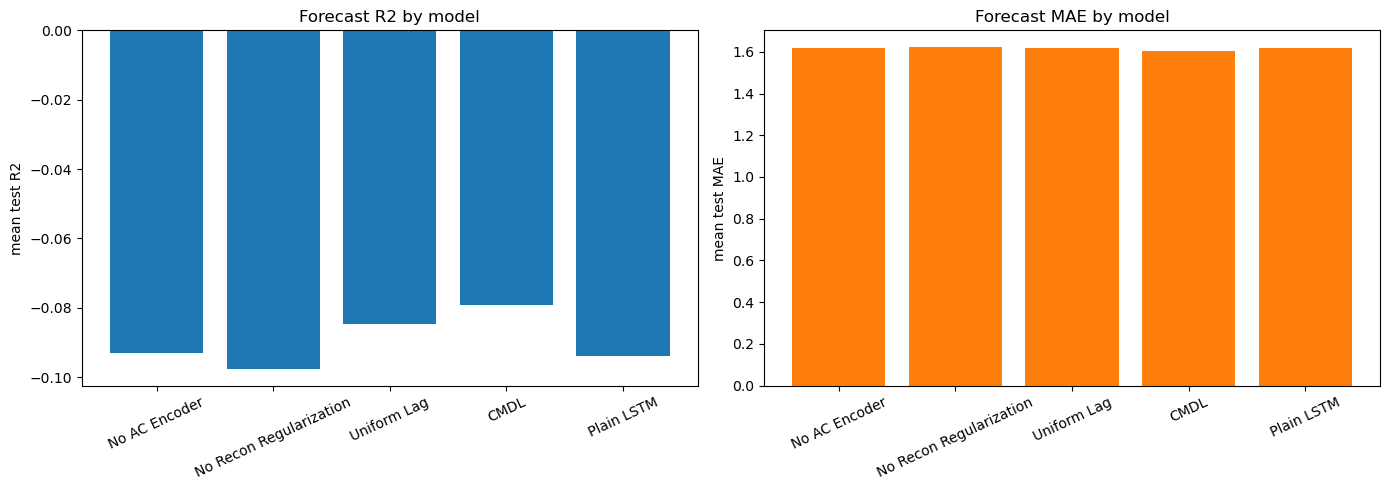

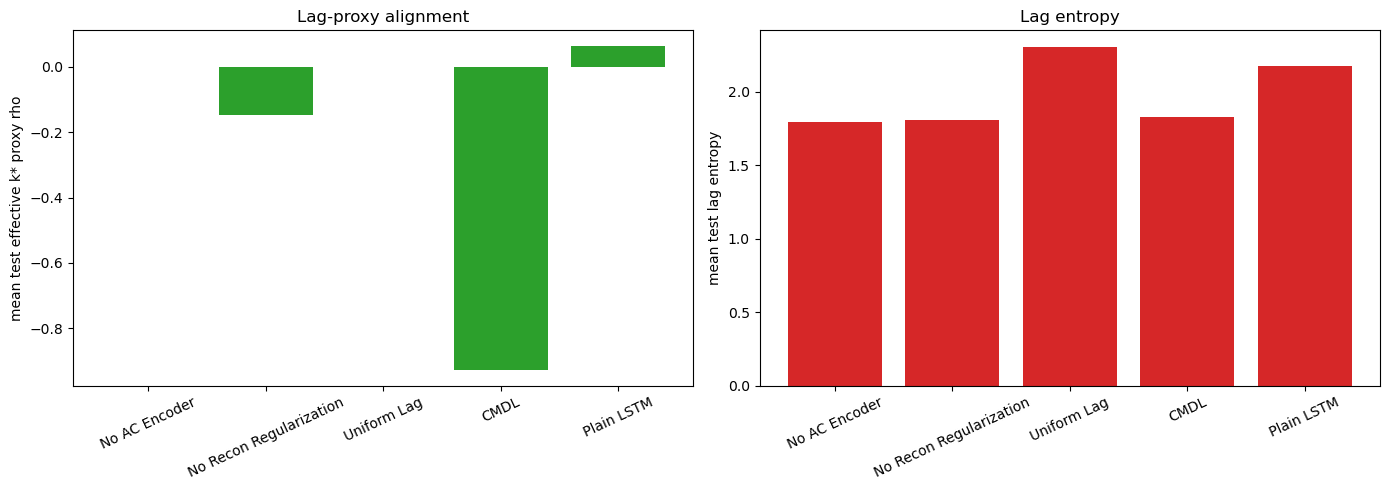

Saved plots to C:\DevSpace\PyDevspace\CMDL\outputs\notebook_economics\formal_target\comparison_plots\forecast_metrics.png and C:\DevSpace\PyDevspace\CMDL\outputs\notebook_economics\formal_target\comparison_plots\lag_proxy_diagnostics.png


In [10]:
if task_seed_summary.empty or interpretability_seed_summary.empty:
    print("No comparison results found yet; skipping plots.")
else:
    forecast_plot_frame = task_seed_summary.copy()
    diagnostics_plot_frame = interpretability_seed_summary.copy()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].bar(forecast_plot_frame["display_name"], forecast_plot_frame["test_r2_mean"], color="#1f77b4")
    axes[0].set_title("Forecast R2 by model")
    axes[0].set_ylabel("mean test R2")
    axes[0].tick_params(axis="x", rotation=25)

    axes[1].bar(forecast_plot_frame["display_name"], forecast_plot_frame["test_mae_mean"], color="#ff7f0e")
    axes[1].set_title("Forecast MAE by model")
    axes[1].set_ylabel("mean test MAE")
    axes[1].tick_params(axis="x", rotation=25)

    fig.tight_layout()
    forecast_plot_path = PLOTS_DIR / "forecast_metrics.png"
    fig.savefig(forecast_plot_path, dpi=160, bbox_inches="tight")
    display(fig)
    plt.close(fig)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].bar(
        diagnostics_plot_frame["display_name"],
        diagnostics_plot_frame["test_effective_kstar_proxy_spearman_rho_mean"],
        color="#2ca02c",
    )
    axes[0].set_title("Lag-proxy alignment")
    axes[0].set_ylabel("mean test effective k* proxy rho")
    axes[0].tick_params(axis="x", rotation=25)

    axes[1].bar(
        diagnostics_plot_frame["display_name"],
        diagnostics_plot_frame["test_effective_lag_entropy_mean_mean"],
        color="#d62728",
    )
    axes[1].set_title("Lag entropy")
    axes[1].set_ylabel("mean test lag entropy")
    axes[1].tick_params(axis="x", rotation=25)

    fig.tight_layout()
    diagnostics_plot_path = PLOTS_DIR / "lag_proxy_diagnostics.png"
    fig.savefig(diagnostics_plot_path, dpi=160, bbox_inches="tight")
    display(fig)
    plt.close(fig)

    print(f"Saved plots to {forecast_plot_path} and {diagnostics_plot_path}")

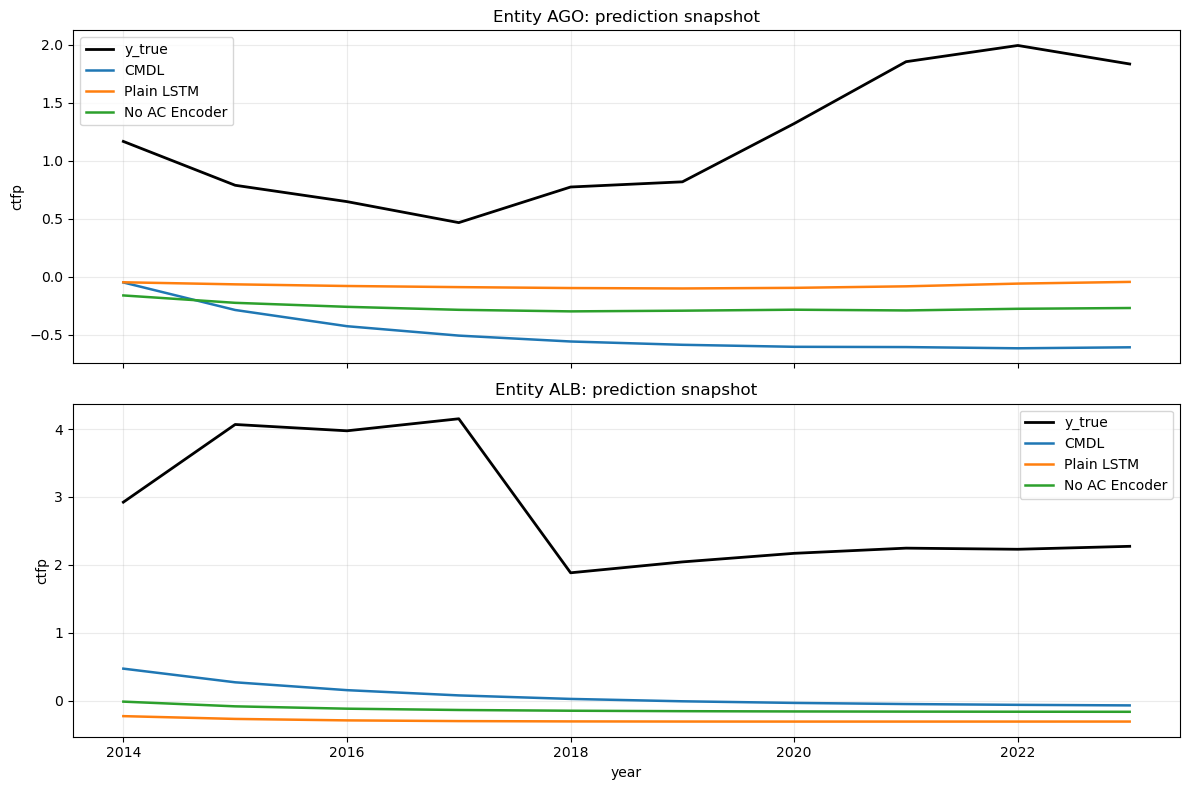

Saved prediction snapshot plot to C:\DevSpace\PyDevspace\CMDL\outputs\notebook_economics\formal_target\comparison_plots\prediction_snapshots.png


In [11]:
prediction_specs = {
    "CMDL": CMDL_OUTPUT_DIR / f"E4_economics_cmdl_seed{CANONICAL_SEED}" / "predictions.csv",
    "Plain LSTM": BASELINE_OUTPUT_DIR / f"E4_economics_lstm_seed{CANONICAL_SEED}" / "predictions.csv",
    "No AC Encoder": ABLATION_OUTPUT_DIR / f"E4_economics_ablation_no_ac_encoder_seed{CANONICAL_SEED}" / "predictions.csv",
}

prediction_frames: dict[str, pd.DataFrame] = {}
for label, path in prediction_specs.items():
    if path.exists():
        prediction_frames[label] = pd.read_csv(path)

if not prediction_frames:
    print("No prediction snapshots found yet; skipping time-series comparison.")
else:
    reference_frame = next(iter(prediction_frames.values()))
    entity_codes = sorted(reference_frame["entity_code"].unique().tolist())[:2]
    fig, axes = plt.subplots(len(entity_codes), 1, figsize=(12, 4 * len(entity_codes)), sharex=True)
    if len(entity_codes) == 1:
        axes = [axes]

    for axis, entity_code in zip(axes, entity_codes):
        baseline_truth = reference_frame[reference_frame["entity_code"] == entity_code]
        axis.plot(baseline_truth["year"], baseline_truth["y_true"], color="black", linewidth=2.0, label="y_true")
        for label, frame in prediction_frames.items():
            entity_frame = frame[frame["entity_code"] == entity_code]
            axis.plot(entity_frame["year"], entity_frame["y_pred"], linewidth=1.8, label=label)
        axis.set_title(f"Entity {entity_code}: prediction snapshot")
        axis.set_ylabel(TARGET_COLUMN)
        axis.grid(alpha=0.25)
        axis.legend()

    axes[-1].set_xlabel("year")
    fig.tight_layout()
    prediction_plot_path = PLOTS_DIR / "prediction_snapshots.png"
    fig.savefig(prediction_plot_path, dpi=160, bbox_inches="tight")
    display(fig)
    plt.close(fig)
    print(f"Saved prediction snapshot plot to {prediction_plot_path}")

## Phase B Screening / Phase B 筛选验证

This section exports a richer Phase B cleaned asset, screens `minimal`, `growth_aware`, and `effective_labor_aware` bundles on both `ctfp` and `rtfpna`, and visualizes forecast plus mechanism diagnostics.
本节导出更丰富的 Phase B 清洗表，对 `minimal`、`growth_aware` 和 `effective_labor_aware` 三个 bundle 在 `ctfp` 和 `rtfpna` 上做快速筛选，并可视化预测与机制诊断结果。

The new `effective_labor_aware` bundle keeps the growth-aware sequential signals but replaces the leading proxy anchor with an effective-labor summary built from `emp * avh`, while retaining human-capital auxiliaries.
新的 `effective_labor_aware` bundle 保留 growth-aware 的时序信号，但把主 proxy 锚点替换为基于 `emp * avh` 的有效劳动摘要，同时保留 human-capital 辅助 proxy。

In [31]:
from argparse import Namespace
import importlib

from data.economics import economics_loader as economics_loader_module
from data.economics import prepare as economics_prepare_module
from evaluation import economics_comparison as economics_comparison_module
from experiments import run_economics as run_economics_module
from experiments import run_economics_lstm_baseline as run_economics_lstm_baseline_module

economics_loader_module = importlib.reload(economics_loader_module)
economics_prepare_module = importlib.reload(economics_prepare_module)
economics_comparison_module = importlib.reload(economics_comparison_module)
run_economics_module = importlib.reload(run_economics_module)
run_economics_lstm_baseline_module = importlib.reload(run_economics_lstm_baseline_module)

save_cleaned_economics_table = economics_prepare_module.save_cleaned_economics_table
DEFAULT_ECONOMICS_CLEANED_V2_OUTPUT_PATH = economics_prepare_module.DEFAULT_ECONOMICS_CLEANED_V2_OUTPUT_PATH
build_economics_comparison = economics_comparison_module.build_economics_comparison
build_task_table = economics_comparison_module.build_task_table
build_interpretability_table = economics_comparison_module.build_interpretability_table
run_cmdl_experiment = run_economics_module.run_experiment
run_baseline_experiment = run_economics_lstm_baseline_module.run_experiment

PHASE_B_SOURCE_PATH = repo_root / "data" / "economics" / "raw" / "pwt110.csv"
PHASE_B_DATA_PATH = DEFAULT_ECONOMICS_CLEANED_V2_OUTPUT_PATH.resolve()
PHASE_B_OUTPUT_ROOT = repo_root / "outputs" / "notebook_economics" / "phase_b_screening"
PHASE_B_CMDL_OUTPUT_DIR = PHASE_B_OUTPUT_ROOT / "cmdl"
PHASE_B_BASELINE_OUTPUT_DIR = PHASE_B_OUTPUT_ROOT / "plain_lstm"
PHASE_B_COMPARISON_DIR = PHASE_B_OUTPUT_ROOT / "comparison"
PHASE_B_PLOTS_DIR = PHASE_B_OUTPUT_ROOT / "comparison_plots"
PHASE_B_FEATURE_BUNDLES = ["minimal", "growth_aware", "effective_labor_aware"]
PHASE_B_TARGETS = ["ctfp", "rtfpna"]
PHASE_B_SEED = 0
PHASE_B_PRESET = {"epochs": 4, "patience": 2, "log_every": 1}
PHASE_B_DEVICE = "cpu"
PHASE_B_DISABLE_MLFLOW = True

if not PHASE_B_SOURCE_PATH.exists():
    raise FileNotFoundError(f"Raw PWT source not found at {PHASE_B_SOURCE_PATH}")

for path in [PHASE_B_OUTPUT_ROOT, PHASE_B_CMDL_OUTPUT_DIR, PHASE_B_BASELINE_OUTPUT_DIR, PHASE_B_COMPARISON_DIR, PHASE_B_PLOTS_DIR]:
    path.mkdir(parents=True, exist_ok=True)

phase_b_cleaned_path = save_cleaned_economics_table(
    csv_path=PHASE_B_SOURCE_PATH,
    output_path=PHASE_B_DATA_PATH,
    target_column="ctfp",
    year_start=COMMON_ARGS["year_start"],
    year_end=COMMON_ARGS["year_end"],
    max_missing_share=COMMON_ARGS["max_missing_share"],
)

phase_b_settings = pd.DataFrame(
    {
        "value": [
            PHASE_B_SOURCE_PATH,
            phase_b_cleaned_path,
            ", ".join(PHASE_B_TARGETS),
            ", ".join(PHASE_B_FEATURE_BUNDLES),
            PHASE_B_SEED,
            PHASE_B_PRESET["epochs"],
            PHASE_B_DEVICE,
            PHASE_B_DISABLE_MLFLOW,
            PHASE_B_OUTPUT_ROOT,
        ]
    },
    index=[
        "PHASE_B_SOURCE_PATH",
        "PHASE_B_DATA_PATH",
        "PHASE_B_TARGETS",
        "PHASE_B_FEATURE_BUNDLES",
        "PHASE_B_SEED",
        "PHASE_B_EPOCHS",
        "PHASE_B_DEVICE",
        "PHASE_B_DISABLE_MLFLOW",
        "PHASE_B_OUTPUT_ROOT",
    ],
)

display(phase_b_settings)
display(pd.read_csv(phase_b_cleaned_path).head())

,value
PHASE_B_SOURCE_PATH,C:\DevSpace\PyDevspace\CMDL\data\economics\raw...
PHASE_B_DATA_PATH,C:\DevSpace\PyDevspace\CMDL\data\economics\pro...
PHASE_B_TARGETS,"ctfp, rtfpna"
PHASE_B_FEATURE_BUNDLES,"minimal, growth_aware, effective_labor_aware"
PHASE_B_SEED,0
PHASE_B_EPOCHS,4
PHASE_B_DEVICE,cpu
PHASE_B_DISABLE_MLFLOW,True
PHASE_B_OUTPUT_ROOT,C:\DevSpace\PyDevspace\CMDL\outputs\notebook_e...


,entity_code,entity_name,year,hc,ck,rgdpna,ctfp,rtfpna,emp,avh,...,log_rgdpna_raw,log_ck_raw,dlog_rgdpna_raw,dlog_ck_raw,hc_was_missing,ck_was_missing,rgdpna_was_missing,ctfp_was_missing,row_was_missing,entity_missing_share
0,AGO,Angola,1980,1.041064,0.004254,56702.734375,0.470326,1.203653,4.238188,2090.41,...,10.945578,-5.459990,0.000000,0.000000,0,0,0,0,0,0.0
1,AGO,Angola,1981,1.050381,0.004349,54207.816406,0.446577,1.113359,4.372468,2090.41,...,10.900580,-5.437800,-0.044997,0.022189,0,0,0,0,0,0.0
2,AGO,Angola,1982,1.059781,0.004534,54207.816406,0.439199,1.072500,4.512469,2090.41,...,10.900580,-5.396147,0.000000,0.041653,0,0,0,0,0,0.0
3,AGO,Angola,1983,1.069264,0.004688,56484.542969,0.412675,1.082048,4.658608,2090.41,...,10.941722,-5.362796,0.041142,0.033351,0,0,0,0,0,0.0
4,AGO,Angola,1984,1.078833,0.004744,59873.617188,0.418729,1.107150,4.808865,2090.41,...,10.999991,-5.350788,0.058269,0.012008,0,0,0,0,0,0.0


In [32]:
phase_b_cmdl_summaries: list[dict[str, object]] = []
phase_b_baseline_summaries: list[dict[str, object]] = []

for target_column in PHASE_B_TARGETS:
    for feature_bundle in PHASE_B_FEATURE_BUNDLES:
        shared_args = {
            **COMMON_ARGS,
            **PHASE_B_PRESET,
            "csv_path": str(PHASE_B_DATA_PATH),
            "target_column": target_column,
            "feature_bundle": feature_bundle,
            "seed": PHASE_B_SEED,
            "device": PHASE_B_DEVICE,
            "disable_mlflow": PHASE_B_DISABLE_MLFLOW,
            "smoke": False,
        }

        cmdl_args = Namespace(
            **shared_args,
            output_dir=str(PHASE_B_CMDL_OUTPUT_DIR),
            experiment_name=f"phase_b_cmdl_{target_column}_{feature_bundle}_seed{PHASE_B_SEED}",
        )
        cmdl_summary = run_cmdl_experiment(cmdl_args)
        phase_b_cmdl_summaries.append(cmdl_summary)
        print(
            f"CMDL target={target_column} bundle={feature_bundle} "
            f"test_r2={cmdl_summary['metrics']['test']['r2']:.4f} "
            f"kstar_std={cmdl_summary['metrics']['test']['kstar_std']:.4f}"
        )

        baseline_args = Namespace(
            **shared_args,
            output_dir=str(PHASE_B_BASELINE_OUTPUT_DIR),
            experiment_name=f"phase_b_lstm_{target_column}_{feature_bundle}_seed{PHASE_B_SEED}",
        )
        baseline_summary = run_baseline_experiment(baseline_args)
        phase_b_baseline_summaries.append(baseline_summary)
        print(
            f"Baseline target={target_column} bundle={feature_bundle} "
            f"test_r2={baseline_summary['metrics']['test']['r2']:.4f} "
            f"kstar_std={baseline_summary['metrics']['test']['posthoc_kstar_std']:.4f}"
        )

phase_b_comparison = build_economics_comparison(
    cmdl_root=PHASE_B_CMDL_OUTPUT_DIR,
    baseline_root=PHASE_B_BASELINE_OUTPUT_DIR,
)
phase_b_task_table = build_task_table(phase_b_comparison)
phase_b_interpretability_table = build_interpretability_table(phase_b_comparison)

phase_b_comparison.to_csv(PHASE_B_COMPARISON_DIR / "phase_b_comparison.csv", index=False)
phase_b_task_table.to_csv(PHASE_B_COMPARISON_DIR / "phase_b_forecast_comparison.csv", index=False)
phase_b_interpretability_table.to_csv(PHASE_B_COMPARISON_DIR / "phase_b_interpretability_comparison.csv", index=False)

display(phase_b_task_table)
display(phase_b_interpretability_table)

[phase_b_cmdl_ctfp_minimal_seed0] epoch=001 train_total=1.3362 val_task=3.0047 val_r2=-0.0753 val_proxy_r2=-0.0018
[phase_b_cmdl_ctfp_minimal_seed0] epoch=002 train_total=1.0875 val_task=3.0235 val_r2=-0.0737 val_proxy_r2=-0.0024
[phase_b_cmdl_ctfp_minimal_seed0] epoch=003 train_total=0.9756 val_task=3.0823 val_r2=-0.0913 val_proxy_r2=-0.0023
[phase_b_cmdl_ctfp_minimal_seed0] early stopping at epoch 3
CMDL target=ctfp bundle=minimal test_r2=-0.0621 kstar_std=0.0182
[phase_b_lstm_ctfp_minimal_seed0] epoch=001 train_task=1.1488 val_task=3.1887 val_mae=1.3745 val_r2=-0.1399
[phase_b_lstm_ctfp_minimal_seed0] epoch=002 train_task=0.9882 val_task=3.0970 val_mae=1.3324 val_r2=-0.1014
[phase_b_lstm_ctfp_minimal_seed0] epoch=003 train_task=0.8878 val_task=3.0137 val_mae=1.3051 val_r2=-0.0673
[phase_b_lstm_ctfp_minimal_seed0] epoch=004 train_task=0.8172 val_task=2.9906 val_mae=1.3057 val_r2=-0.0571
Baseline target=ctfp bundle=minimal test_r2=-0.1191 kstar_std=1.2482
[phase_b_cmdl_ctfp_growth_awa

,display_name,family,variant,seed,experiment,target_column,feature_bundle,best_epoch,best_val_task_loss,test_r2,test_mae,test_mse
0,CMDL,cmdl,None,0,phase_b_cmdl_ctfp_effective_labor_aware_seed0,ctfp,effective_labor_aware,4,2.766690,-0.027351,1.551346,4.125605
1,Plain LSTM,plain_lstm,None,0,phase_b_lstm_ctfp_effective_labor_aware_seed0,ctfp,effective_labor_aware,4,2.775850,-0.032187,1.546390,4.146410
2,CMDL,cmdl,None,0,phase_b_cmdl_ctfp_growth_aware_seed0,ctfp,growth_aware,4,2.818765,-0.053619,1.590008,4.370918
3,Plain LSTM,plain_lstm,None,0,phase_b_lstm_ctfp_growth_aware_seed0,ctfp,growth_aware,3,2.963819,-0.059547,1.594493,4.395070
4,CMDL,cmdl,None,0,phase_b_cmdl_ctfp_minimal_seed0,ctfp,minimal,1,3.004729,-0.062092,1.624442,4.403859
5,Plain LSTM,plain_lstm,None,0,phase_b_lstm_ctfp_minimal_seed0,ctfp,minimal,4,2.990565,-0.119073,1.636646,4.638017
6,Plain LSTM,plain_lstm,None,0,phase_b_lstm_rtfpna_effective_labor_aware_seed0,rtfpna,effective_labor_aware,4,2.597628,0.057197,1.691592,4.829085
7,CMDL,cmdl,None,0,phase_b_cmdl_rtfpna_effective_labor_aware_seed0,rtfpna,effective_labor_aware,1,2.901220,-0.033655,1.754396,5.300596
8,Plain LSTM,plain_lstm,None,0,phase_b_lstm_rtfpna_growth_aware_seed0,rtfpna,growth_aware,4,2.653783,0.058082,1.691044,4.835533
9,CMDL,cmdl,None,0,phase_b_cmdl_rtfpna_growth_aware_seed0,rtfpna,growth_aware,4,2.856803,0.040156,1.721228,4.911241


,display_name,family,variant,seed,experiment,target_column,feature_bundle,lag_method,proxy_refit_status,proxy_metric_interpretable,test_effective_kstar_proxy_spearman_rho,test_effective_kstar_proxy_metric_valid,test_effective_kstar_mean,test_effective_kstar_std,test_effective_lag_entropy_mean,test_proxy_signal_r2,test_proxy_signal_metric_valid
0,Plain LSTM,plain_lstm,None,0,phase_b_lstm_ctfp_effective_labor_aware_seed0,ctfp,effective_labor_aware,lag_occlusion,None,None,0.004141,None,5.744873,1.946034,1.889462,NaN,None
1,CMDL,cmdl,None,0,phase_b_cmdl_ctfp_effective_labor_aware_seed0,ctfp,effective_labor_aware,learned_omega,applied_ols,True,-0.313076,True,2.951077,0.017659,1.689239,0.185955,True
2,CMDL,cmdl,None,0,phase_b_cmdl_ctfp_growth_aware_seed0,ctfp,growth_aware,learned_omega,applied_ols,True,0.898797,True,4.807130,0.083969,1.916423,0.458875,True
3,Plain LSTM,plain_lstm,None,0,phase_b_lstm_ctfp_growth_aware_seed0,ctfp,growth_aware,lag_occlusion,None,None,0.106768,None,5.588688,2.062071,1.866780,NaN,None
4,Plain LSTM,plain_lstm,None,0,phase_b_lstm_ctfp_minimal_seed0,ctfp,minimal,lag_occlusion,None,None,0.002569,None,5.400427,1.248228,2.146393,NaN,None
5,CMDL,cmdl,None,0,phase_b_cmdl_ctfp_minimal_seed0,ctfp,minimal,learned_omega,applied_ols,True,-0.473761,True,5.386937,0.018225,1.817613,0.339445,True
6,Plain LSTM,plain_lstm,None,0,phase_b_lstm_rtfpna_effective_labor_aware_seed0,rtfpna,effective_labor_aware,lag_occlusion,None,None,0.029842,None,5.398258,1.772078,1.966255,NaN,None
7,CMDL,cmdl,None,0,phase_b_cmdl_rtfpna_effective_labor_aware_seed0,rtfpna,effective_labor_aware,learned_omega,applied_ols,True,-0.407030,True,3.017542,0.012506,1.706605,0.202868,True
8,CMDL,cmdl,None,0,phase_b_cmdl_rtfpna_growth_aware_seed0,rtfpna,growth_aware,learned_omega,applied_ols,True,0.910118,True,4.838705,0.075644,1.914742,0.436625,True
9,Plain LSTM,plain_lstm,None,0,phase_b_lstm_rtfpna_growth_aware_seed0,rtfpna,growth_aware,lag_occlusion,None,None,-0.088945,None,5.073704,1.738850,1.908179,NaN,None


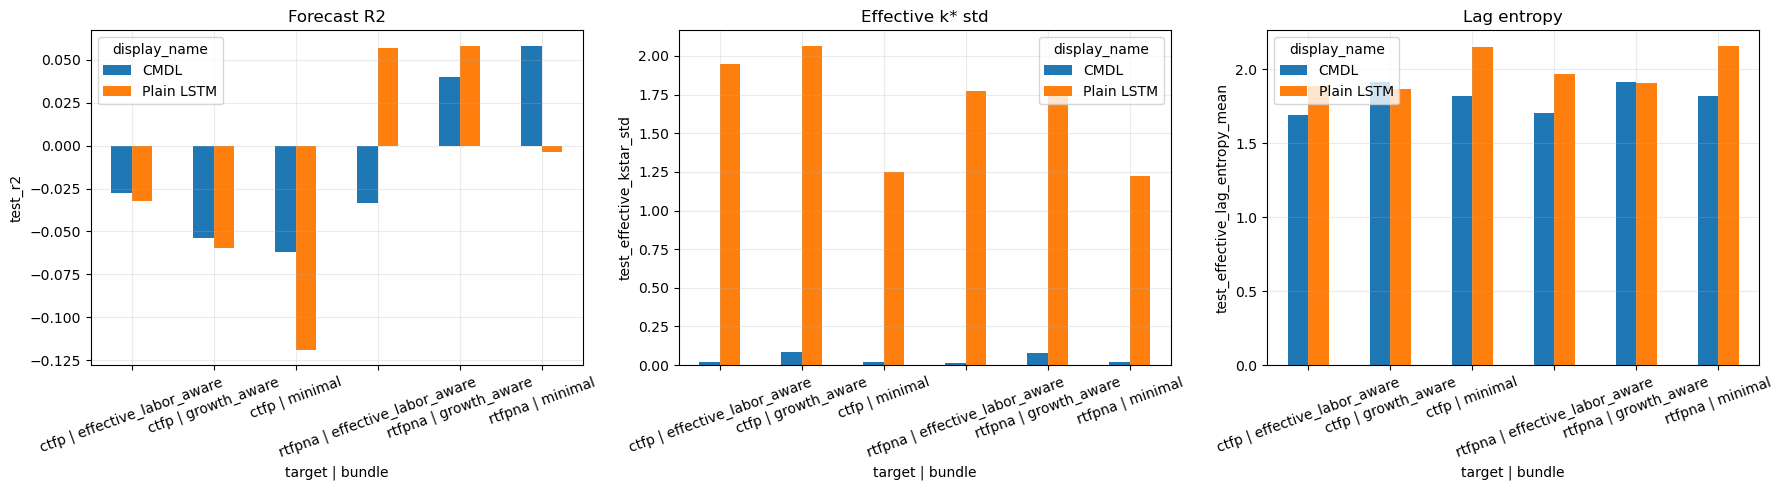

,target_column,feature_bundle,display_name,test_r2,test_effective_kstar_std,test_effective_lag_entropy_mean,test_effective_kstar_proxy_spearman_rho,test_proxy_signal_r2,proxy_refit_status
0,ctfp,effective_labor_aware,CMDL,-0.027351,0.017659,1.689239,-0.313076,0.185955,applied_ols
2,ctfp,growth_aware,CMDL,-0.053619,0.083969,1.916423,0.898797,0.458875,applied_ols
4,ctfp,minimal,CMDL,-0.062092,0.018225,1.817613,-0.473761,0.339445,applied_ols
6,rtfpna,effective_labor_aware,CMDL,-0.033655,0.012506,1.706605,-0.407030,0.202868,applied_ols
8,rtfpna,growth_aware,CMDL,0.040156,0.075644,1.914742,0.910118,0.436625,applied_ols
10,rtfpna,minimal,CMDL,0.058391,0.022191,1.815753,-0.491167,0.395200,applied_ols


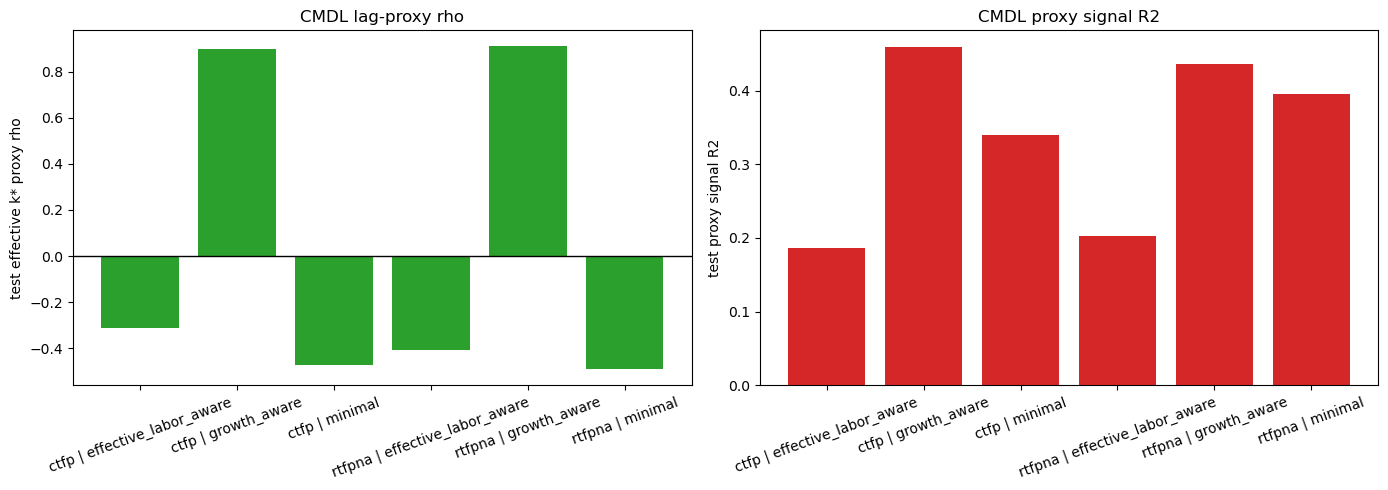

Saved Phase B plots to C:\DevSpace\PyDevspace\CMDL\outputs\notebook_economics\phase_b_screening\comparison_plots\phase_b_screening_metrics.png and C:\DevSpace\PyDevspace\CMDL\outputs\notebook_economics\phase_b_screening\comparison_plots\phase_b_mechanism_diagnostics.png


In [33]:
if phase_b_comparison.empty:
    print("No Phase B screening results found; skipping plots.")
else:
    phase_b_plot_frame = phase_b_comparison.copy()
    phase_b_plot_frame["setting_label"] = (
        phase_b_plot_frame["target_column"] + " | " + phase_b_plot_frame["feature_bundle"]
    )

    metrics_to_plot = [
        ("test_r2", "Forecast R2"),
        ("test_effective_kstar_std", "Effective k* std"),
        ("test_effective_lag_entropy_mean", "Lag entropy"),
    ]
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for axis, (metric_name, title) in zip(axes, metrics_to_plot):
        pivot = phase_b_plot_frame.pivot(
            index="setting_label",
            columns="display_name",
            values=metric_name,
        ).sort_index()
        pivot.plot(kind="bar", ax=axis)
        axis.set_title(title)
        axis.set_xlabel("target | bundle")
        axis.set_ylabel(metric_name)
        axis.tick_params(axis="x", rotation=20)
        axis.grid(alpha=0.25)
    fig.tight_layout()
    phase_b_metrics_plot_path = PHASE_B_PLOTS_DIR / "phase_b_screening_metrics.png"
    fig.savefig(phase_b_metrics_plot_path, dpi=160, bbox_inches="tight")
    display(fig)
    plt.close(fig)

    phase_b_cmdl_only = phase_b_plot_frame.loc[phase_b_plot_frame["family"] == "cmdl"].copy()
    display(
        phase_b_cmdl_only[
            [
                "target_column",
                "feature_bundle",
                "display_name",
                "test_r2",
                "test_effective_kstar_std",
                "test_effective_lag_entropy_mean",
                "test_effective_kstar_proxy_spearman_rho",
                "test_proxy_signal_r2",
                "proxy_refit_status",
            ]
        ].sort_values(["target_column", "feature_bundle"])
    )

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].bar(
        phase_b_cmdl_only["setting_label"],
        phase_b_cmdl_only["test_effective_kstar_proxy_spearman_rho"].fillna(0.0),
        color="#2ca02c",
    )
    axes[0].axhline(0.0, color="black", linewidth=1.0)
    axes[0].set_title("CMDL lag-proxy rho")
    axes[0].set_ylabel("test effective k* proxy rho")
    axes[0].tick_params(axis="x", rotation=20)

    axes[1].bar(
        phase_b_cmdl_only["setting_label"],
        phase_b_cmdl_only["test_proxy_signal_r2"].fillna(0.0),
        color="#d62728",
    )
    axes[1].set_title("CMDL proxy signal R2")
    axes[1].set_ylabel("test proxy signal R2")
    axes[1].tick_params(axis="x", rotation=20)

    fig.tight_layout()
    phase_b_mechanism_plot_path = PHASE_B_PLOTS_DIR / "phase_b_mechanism_diagnostics.png"
    fig.savefig(phase_b_mechanism_plot_path, dpi=160, bbox_inches="tight")
    display(fig)
    plt.close(fig)

    print(f"Saved Phase B plots to {phase_b_metrics_plot_path} and {phase_b_mechanism_plot_path}")

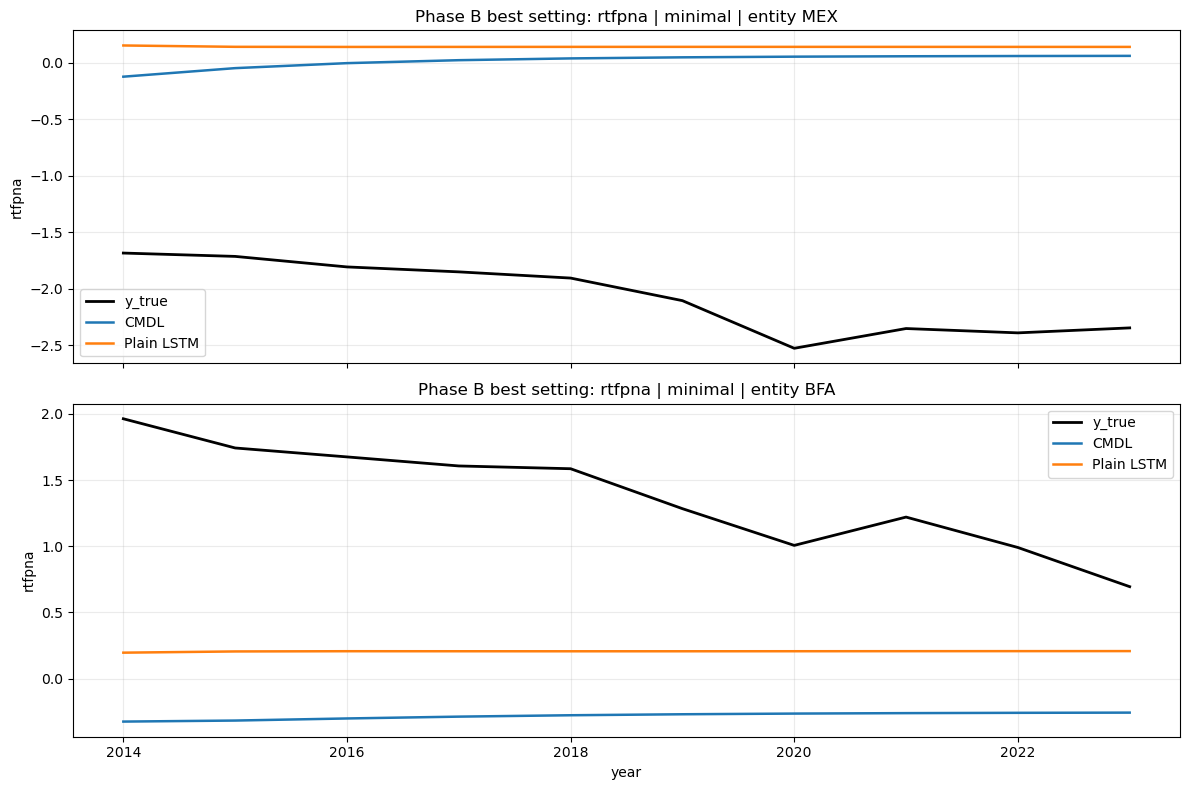

Saved Phase B prediction snapshots to C:\DevSpace\PyDevspace\CMDL\outputs\notebook_economics\phase_b_screening\comparison_plots\phase_b_prediction_snapshots.png


In [34]:
if phase_b_comparison.empty:
    print("No Phase B screening results found; skipping prediction snapshots.")
else:
    phase_b_best_cmdl = phase_b_comparison.loc[phase_b_comparison["family"] == "cmdl"].sort_values(
        ["test_r2", "test_effective_kstar_std"],
        ascending=[False, False],
        na_position="last",
    ).iloc[0]
    phase_b_best_baseline = phase_b_comparison.loc[
        (phase_b_comparison["family"] == "plain_lstm")
        & (phase_b_comparison["target_column"] == phase_b_best_cmdl["target_column"])
        & (phase_b_comparison["feature_bundle"] == phase_b_best_cmdl["feature_bundle"])
    ].iloc[0]

    phase_b_prediction_specs = {
        "CMDL": Path(phase_b_best_cmdl["run_dir"]) / "predictions.csv",
        "Plain LSTM": Path(phase_b_best_baseline["run_dir"]) / "predictions.csv",
    }
    phase_b_prediction_frames: dict[str, pd.DataFrame] = {}
    for label, path in phase_b_prediction_specs.items():
        if path.exists():
            phase_b_prediction_frames[label] = pd.read_csv(path)

    if not phase_b_prediction_frames:
        print("Prediction files are missing; skipping Phase B prediction snapshots.")
    else:
        reference_frame = phase_b_prediction_frames["CMDL"]
        if "k_star" in reference_frame.columns:
            kstar_by_entity = reference_frame.groupby("entity_code", as_index=False)["k_star"].first().sort_values("k_star")
            candidate_codes = kstar_by_entity["entity_code"].tolist()
            entity_codes = candidate_codes[:1] + candidate_codes[-1:]
            entity_codes = list(dict.fromkeys(entity_codes))
        else:
            entity_codes = sorted(reference_frame["entity_code"].unique().tolist())[:2]

        fig, axes = plt.subplots(len(entity_codes), 1, figsize=(12, 4 * len(entity_codes)), sharex=True)
        if len(entity_codes) == 1:
            axes = [axes]

        for axis, entity_code in zip(axes, entity_codes):
            truth_frame = reference_frame[reference_frame["entity_code"] == entity_code]
            axis.plot(truth_frame["year"], truth_frame["y_true"], color="black", linewidth=2.0, label="y_true")
            for label, frame in phase_b_prediction_frames.items():
                entity_frame = frame[frame["entity_code"] == entity_code]
                axis.plot(entity_frame["year"], entity_frame["y_pred"], linewidth=1.8, label=label)
            axis.set_title(
                f"Phase B best setting: {phase_b_best_cmdl['target_column']} | {phase_b_best_cmdl['feature_bundle']} | entity {entity_code}"
            )
            axis.set_ylabel(phase_b_best_cmdl["target_column"])
            axis.grid(alpha=0.25)
            axis.legend()

        axes[-1].set_xlabel("year")
        fig.tight_layout()
        phase_b_prediction_plot_path = PHASE_B_PLOTS_DIR / "phase_b_prediction_snapshots.png"
        fig.savefig(phase_b_prediction_plot_path, dpi=160, bbox_inches="tight")
        display(fig)
        plt.close(fig)
        print(f"Saved Phase B prediction snapshots to {phase_b_prediction_plot_path}")

## Formal Mechanism Suite / 正式机制验证

This section upgrades the strongest economics mechanism claim from Phase B screening to a formal suite: `ctfp` + `effective_labor_aware`, three seeds, and same-bundle ablations.
本节把 Phase B 中强化后的 proxy 设计升级为正式验证：`ctfp` + `effective_labor_aware`，3 个随机种子，并加入同 bundle 的 ablation 来检验必要性。

The leading proxy is now an effective-labor anchor built from `emp * avh`, so the formal k* alignment check is no longer tied only to average human capital.
现在 formal k* 对齐检验的主 proxy 锚点改为基于 `emp * avh` 的有效劳动摘要，不再只绑定到平均 human capital。

In [35]:
import importlib

from experiments import run_economics_ablation as run_economics_ablation_module

run_economics_ablation_module = importlib.reload(run_economics_ablation_module)
run_ablation_suite = run_economics_ablation_module.run_suite

FORMAL_MECHANISM_TARGET = "ctfp"
FORMAL_MECHANISM_FEATURE_BUNDLE = "effective_labor_aware"
FORMAL_MECHANISM_SEEDS = [0, 1, 2]
FORMAL_MECHANISM_PRESET = dict(PRESET_CONFIGS["formal_target"])
FORMAL_MECHANISM_DEVICE = "cpu"
FORMAL_MECHANISM_DISABLE_MLFLOW = True
FORMAL_MECHANISM_DATA_PATH = PHASE_B_DATA_PATH
FORMAL_MECHANISM_OUTPUT_ROOT = repo_root / "outputs" / "notebook_economics" / "formal_mechanism_ctfp_effective_labor_aware"
FORMAL_MECHANISM_CMDL_DIR = FORMAL_MECHANISM_OUTPUT_ROOT / "cmdl"
FORMAL_MECHANISM_BASELINE_DIR = FORMAL_MECHANISM_OUTPUT_ROOT / "plain_lstm"
FORMAL_MECHANISM_ABLATION_DIR = FORMAL_MECHANISM_OUTPUT_ROOT / "ablation"
FORMAL_MECHANISM_COMPARISON_DIR = FORMAL_MECHANISM_OUTPUT_ROOT / "comparison"
FORMAL_MECHANISM_PLOTS_DIR = FORMAL_MECHANISM_OUTPUT_ROOT / "comparison_plots"

for path in [
    FORMAL_MECHANISM_OUTPUT_ROOT,
    FORMAL_MECHANISM_CMDL_DIR,
    FORMAL_MECHANISM_BASELINE_DIR,
    FORMAL_MECHANISM_ABLATION_DIR,
    FORMAL_MECHANISM_COMPARISON_DIR,
    FORMAL_MECHANISM_PLOTS_DIR,
]:
    path.mkdir(parents=True, exist_ok=True)

formal_mechanism_settings = pd.DataFrame(
    {
        "value": [
            FORMAL_MECHANISM_DATA_PATH,
            FORMAL_MECHANISM_TARGET,
            FORMAL_MECHANISM_FEATURE_BUNDLE,
            ", ".join(str(seed) for seed in FORMAL_MECHANISM_SEEDS),
            FORMAL_MECHANISM_PRESET["epochs"],
            FORMAL_MECHANISM_PRESET["patience"],
            FORMAL_MECHANISM_DEVICE,
            FORMAL_MECHANISM_DISABLE_MLFLOW,
            FORMAL_MECHANISM_OUTPUT_ROOT,
        ]
    },
    index=[
        "FORMAL_MECHANISM_DATA_PATH",
        "FORMAL_MECHANISM_TARGET",
        "FORMAL_MECHANISM_FEATURE_BUNDLE",
        "FORMAL_MECHANISM_SEEDS",
        "FORMAL_MECHANISM_EPOCHS",
        "FORMAL_MECHANISM_PATIENCE",
        "FORMAL_MECHANISM_DEVICE",
        "FORMAL_MECHANISM_DISABLE_MLFLOW",
        "FORMAL_MECHANISM_OUTPUT_ROOT",
    ],
)

display(formal_mechanism_settings)

,value
FORMAL_MECHANISM_DATA_PATH,C:\DevSpace\PyDevspace\CMDL\data\economics\pro...
FORMAL_MECHANISM_TARGET,ctfp
FORMAL_MECHANISM_FEATURE_BUNDLE,effective_labor_aware
FORMAL_MECHANISM_SEEDS,"0, 1, 2"
FORMAL_MECHANISM_EPOCHS,120
FORMAL_MECHANISM_PATIENCE,20
FORMAL_MECHANISM_DEVICE,cpu
FORMAL_MECHANISM_DISABLE_MLFLOW,True
FORMAL_MECHANISM_OUTPUT_ROOT,C:\DevSpace\PyDevspace\CMDL\outputs\notebook_e...


In [36]:
formal_cmdl_summaries: list[dict[str, object]] = []
formal_baseline_summaries: list[dict[str, object]] = []

for seed in FORMAL_MECHANISM_SEEDS:
    shared_args = {
        **COMMON_ARGS,
        **FORMAL_MECHANISM_PRESET,
        "csv_path": str(FORMAL_MECHANISM_DATA_PATH),
        "target_column": FORMAL_MECHANISM_TARGET,
        "feature_bundle": FORMAL_MECHANISM_FEATURE_BUNDLE,
        "seed": seed,
        "device": FORMAL_MECHANISM_DEVICE,
        "disable_mlflow": FORMAL_MECHANISM_DISABLE_MLFLOW,
        "smoke": False,
    }

    cmdl_args = Namespace(
        **shared_args,
        output_dir=str(FORMAL_MECHANISM_CMDL_DIR),
        experiment_name=f"formal_mechanism_cmdl_seed{seed}",
    )
    cmdl_summary = run_cmdl_experiment(cmdl_args)
    formal_cmdl_summaries.append(cmdl_summary)
    print(
        f"CMDL seed={seed} test_r2={cmdl_summary['metrics']['test']['r2']:.4f} "
        f"rho={cmdl_summary['metrics']['test']['kstar_proxy_spearman_rho']:.4f} "
        f"kstar_std={cmdl_summary['metrics']['test']['kstar_std']:.4f}"
    )

    baseline_args = Namespace(
        **shared_args,
        output_dir=str(FORMAL_MECHANISM_BASELINE_DIR),
        experiment_name=f"formal_mechanism_lstm_seed{seed}",
    )
    baseline_summary = run_baseline_experiment(baseline_args)
    formal_baseline_summaries.append(baseline_summary)
    print(
        f"Baseline seed={seed} test_r2={baseline_summary['metrics']['test']['r2']:.4f} "
        f"rho={baseline_summary['metrics']['test']['posthoc_kstar_proxy_spearman_rho']:.4f} "
        f"kstar_std={baseline_summary['metrics']['test']['posthoc_kstar_std']:.4f}"
    )

formal_ablation_shared_args = {
    **COMMON_ARGS,
    **FORMAL_MECHANISM_PRESET,
    "csv_path": str(FORMAL_MECHANISM_DATA_PATH),
    "target_column": FORMAL_MECHANISM_TARGET,
    "feature_bundle": FORMAL_MECHANISM_FEATURE_BUNDLE,
    "seeds": FORMAL_MECHANISM_SEEDS,
    "variant": "all",
    "output_dir": str(FORMAL_MECHANISM_ABLATION_DIR),
    "experiment_prefix": "formal_mechanism_ablation",
    "device": FORMAL_MECHANISM_DEVICE,
    "disable_mlflow": FORMAL_MECHANISM_DISABLE_MLFLOW,
    "smoke": False,
}
formal_ablation_args = Namespace(**formal_ablation_shared_args)
formal_ablation_summary_frame, formal_ablation_aggregated_frame = run_ablation_suite(formal_ablation_args)
if not formal_ablation_aggregated_frame.empty:
    display(formal_ablation_aggregated_frame)

[formal_mechanism_cmdl_seed0] epoch=001 train_total=1.9554 val_task=2.9875 val_r2=-0.0794 val_proxy_r2=-0.3863
[formal_mechanism_cmdl_seed0] epoch=010 train_total=0.6966 val_task=2.4861 val_r2=0.1122 val_proxy_r2=-0.3843
[formal_mechanism_cmdl_seed0] epoch=020 train_total=0.5259 val_task=2.4845 val_r2=0.0938 val_proxy_r2=-0.3720
[formal_mechanism_cmdl_seed0] epoch=030 train_total=0.4142 val_task=2.4708 val_r2=0.0984 val_proxy_r2=-0.3729
[formal_mechanism_cmdl_seed0] early stopping at epoch 37
CMDL seed=0 test_r2=0.0462 rho=-0.2251 kstar_std=0.0403
[formal_mechanism_lstm_seed0] epoch=001 train_task=1.1784 val_task=2.9470 val_mae=1.3152 val_r2=-0.0617
[formal_mechanism_lstm_seed0] epoch=010 train_task=0.5743 val_task=2.7417 val_mae=1.2351 val_r2=0.0268
[formal_mechanism_lstm_seed0] epoch=020 train_task=0.4239 val_task=2.6468 val_mae=1.2794 val_r2=0.0375
[formal_mechanism_lstm_seed0] epoch=030 train_task=0.2975 val_task=2.7543 val_mae=1.3102 val_r2=-0.0107
[formal_mechanism_lstm_seed0] ea

,variant,target_column,effective_lambda_r_mean,effective_lambda_r_std,best_epoch_mean,best_epoch_std,best_val_task_loss_mean,best_val_task_loss_std,proxy_refit_applied_mean,proxy_refit_applied_std,...,test_kstar_proxy_spearman_p_mean,test_kstar_proxy_spearman_p_std,test_kstar_mean_mean,test_kstar_mean_std,test_kstar_std_mean,test_kstar_std_std,test_kstar_proxy_metric_valid_mean,test_kstar_proxy_metric_valid_std,test_omega_entropy_mean_mean,test_omega_entropy_mean_std
0,no_ac_encoder,ctfp,0.0,0.0,24.000000,1.000000,2.556360,0.020832,0.0,0.0,...,1.000000,0.000000,3.803706,0.742061,3.042560e-07,5.701692e-08,1.0,0.0,1.910706,0.103414
1,no_recon_regularization,ctfp,0.0,0.0,24.333333,1.154701,2.561524,0.024942,1.0,0.0,...,0.000117,0.000202,3.787785,0.737952,6.421177e-02,1.689080e-02,1.0,0.0,1.913915,0.100659
2,uniform_lag,ctfp,0.1,0.0,38.000000,25.119713,2.484212,0.065004,1.0,0.0,...,NaN,NaN,5.500000,0.000000,0.000000e+00,0.000000e+00,0.0,0.0,2.302585,0.000000


In [37]:
formal_mechanism_comparison = build_economics_comparison(
    cmdl_root=FORMAL_MECHANISM_CMDL_DIR,
    baseline_root=FORMAL_MECHANISM_BASELINE_DIR,
    ablation_root=FORMAL_MECHANISM_ABLATION_DIR,
)
formal_mechanism_task_table = build_task_table(formal_mechanism_comparison)
formal_mechanism_interpretability_table = build_interpretability_table(formal_mechanism_comparison)

formal_mechanism_comparison.to_csv(FORMAL_MECHANISM_COMPARISON_DIR / "formal_mechanism_comparison.csv", index=False)
formal_mechanism_task_table.to_csv(FORMAL_MECHANISM_COMPARISON_DIR / "formal_mechanism_forecast_comparison.csv", index=False)
formal_mechanism_interpretability_table.to_csv(FORMAL_MECHANISM_COMPARISON_DIR / "formal_mechanism_interpretability_comparison.csv", index=False)

def aggregate_mechanism_summary(frame: pd.DataFrame) -> pd.DataFrame:
    metrics = [
        "test_r2",
        "test_effective_kstar_proxy_spearman_rho",
        "test_effective_kstar_std",
        "test_effective_lag_entropy_mean",
        "test_proxy_signal_r2",
    ]
    aggregated = frame.groupby(["display_name", "family", "variant"], dropna=False)[metrics].agg(["mean", "std"])
    aggregated.columns = [
        column if isinstance(column, str) else "_".join(part for part in column if part)
        for column in aggregated.columns.to_flat_index()
    ]
    aggregated = aggregated.reset_index()
    sign_rows: list[dict[str, object]] = []
    for (display_name, family, variant), group in frame.groupby(["display_name", "family", "variant"], dropna=False):
        rho_series = group["test_effective_kstar_proxy_spearman_rho"].dropna()
        positive_share = float((rho_series > 0.0).mean()) if not rho_series.empty else np.nan
        negative_share = float((rho_series < 0.0).mean()) if not rho_series.empty else np.nan
        if rho_series.empty:
            dominant_sign = "none"
            sign_consistency_share = np.nan
            rho_all_same_sign = False
        elif positive_share > negative_share:
            dominant_sign = "positive"
            sign_consistency_share = positive_share
            rho_all_same_sign = bool((rho_series > 0.0).all())
        elif negative_share > positive_share:
            dominant_sign = "negative"
            sign_consistency_share = negative_share
            rho_all_same_sign = bool((rho_series < 0.0).all())
        else:
            dominant_sign = "mixed"
            sign_consistency_share = positive_share
            rho_all_same_sign = False
        sign_rows.append(
            {
                "display_name": display_name,
                "family": family,
                "variant": variant,
                "rho_positive_seed_share": positive_share,
                "rho_negative_seed_share": negative_share,
                "rho_sign_consistency_share": sign_consistency_share,
                "rho_all_same_sign": rho_all_same_sign,
                "rho_dominant_sign": dominant_sign,
                "seed_count": int(group["seed"].nunique()),
            }
        )
    sign_frame = pd.DataFrame(sign_rows)
    return aggregated.merge(sign_frame, on=["display_name", "family", "variant"], how="left")

formal_mechanism_summary = aggregate_mechanism_summary(formal_mechanism_comparison)
formal_mechanism_summary.to_csv(FORMAL_MECHANISM_COMPARISON_DIR / "formal_mechanism_seed_summary.csv", index=False)

display(formal_mechanism_task_table)
display(formal_mechanism_interpretability_table)
display(formal_mechanism_summary.sort_values(["family", "display_name"], na_position="last"))

,display_name,family,variant,seed,experiment,target_column,feature_bundle,best_epoch,best_val_task_loss,test_r2,test_mae,test_mse
0,Plain LSTM,plain_lstm,None,2,formal_mechanism_lstm_seed2,ctfp,effective_labor_aware,29,2.417332,0.117731,1.434688,3.540757
1,Uniform Lag,ablation,uniform_lag,0,formal_mechanism_ablation_uniform_lag_seed0,ctfp,effective_labor_aware,23,2.490095,0.113794,1.443418,3.563626
2,Plain LSTM,plain_lstm,None,1,formal_mechanism_lstm_seed1,ctfp,effective_labor_aware,26,2.562223,0.105028,1.460540,3.595400
3,Uniform Lag,ablation,uniform_lag,1,formal_mechanism_ablation_uniform_lag_seed1,ctfp,effective_labor_aware,24,2.546074,0.091574,1.456077,3.649394
4,Plain LSTM,plain_lstm,None,0,formal_mechanism_lstm_seed0,ctfp,effective_labor_aware,18,2.614884,0.074373,1.472051,3.718893
5,CMDL,cmdl,None,1,formal_mechanism_cmdl_seed1,ctfp,effective_labor_aware,25,2.450759,0.072451,1.473570,3.731708
6,CMDL,cmdl,None,2,formal_mechanism_cmdl_seed2,ctfp,effective_labor_aware,65,2.403199,0.069775,1.479105,3.737314
7,No AC Encoder,ablation,no_ac_encoder,1,formal_mechanism_ablation_no_ac_encoder_seed1,ctfp,effective_labor_aware,24,2.578570,0.067986,1.467429,3.743416
8,No Recon Regularization,ablation,no_recon_regularization,1,formal_mechanism_ablation_no_recon_regularizat...,ctfp,effective_labor_aware,25,2.585603,0.066536,1.469881,3.749483
9,No AC Encoder,ablation,no_ac_encoder,2,formal_mechanism_ablation_no_ac_encoder_seed2,ctfp,effective_labor_aware,25,2.553255,0.052570,1.499092,3.806588


,display_name,family,variant,seed,experiment,target_column,feature_bundle,lag_method,proxy_refit_status,proxy_metric_interpretable,test_effective_kstar_proxy_spearman_rho,test_effective_kstar_proxy_metric_valid,test_effective_kstar_mean,test_effective_kstar_std,test_effective_lag_entropy_mean,test_proxy_signal_r2,test_proxy_signal_metric_valid
0,No Recon Regularization,ablation,no_recon_regularization,0,formal_mechanism_ablation_no_recon_regularizat...,ctfp,effective_labor_aware,learned_omega,applied_ols,True,0.888979,True,3.066039,4.605718e-02,1.798056,0.382450,True
1,No Recon Regularization,ablation,no_recon_regularization,2,formal_mechanism_ablation_no_recon_regularizat...,ctfp,effective_labor_aware,learned_omega,applied_ols,True,0.612765,True,3.756376,7.946218e-02,1.963793,0.309562,True
2,No Recon Regularization,ablation,no_recon_regularization,1,formal_mechanism_ablation_no_recon_regularizat...,ctfp,effective_labor_aware,learned_omega,applied_ols,True,0.372636,True,4.540939,6.711595e-02,1.979895,0.251640,True
3,Plain LSTM,plain_lstm,None,1,formal_mechanism_lstm_seed1,ctfp,effective_labor_aware,lag_occlusion,None,None,0.104983,None,5.362722,1.985642e+00,1.843047,NaN,None
4,Plain LSTM,plain_lstm,None,2,formal_mechanism_lstm_seed2,ctfp,effective_labor_aware,lag_occlusion,None,None,0.046337,None,5.467198,1.672183e+00,1.981707,NaN,None
5,CMDL,cmdl,None,1,formal_mechanism_cmdl_seed1,ctfp,effective_labor_aware,learned_omega,applied_ols,True,0.036895,True,4.021144,7.622060e-03,1.931944,0.219966,True
6,No AC Encoder,ablation,no_ac_encoder,0,formal_mechanism_ablation_no_ac_encoder_seed0,ctfp,effective_labor_aware,learned_omega,skipped_rank_deficient,False,0.000000,True,3.111291,3.371748e-07,1.791826,NaN,False
7,No AC Encoder,ablation,no_ac_encoder,1,formal_mechanism_ablation_no_ac_encoder_seed1,ctfp,effective_labor_aware,learned_omega,skipped_rank_deficient,False,0.000000,True,4.587036,3.371748e-07,1.979896,NaN,False
8,No AC Encoder,ablation,no_ac_encoder,2,formal_mechanism_ablation_no_ac_encoder_seed2,ctfp,effective_labor_aware,learned_omega,skipped_rank_deficient,False,0.000000,True,3.712791,2.384186e-07,1.960398,NaN,False
9,Plain LSTM,plain_lstm,None,0,formal_mechanism_lstm_seed0,ctfp,effective_labor_aware,lag_occlusion,None,None,-0.161988,None,5.703390,1.910323e+00,1.862576,NaN,None


,display_name,family,variant,test_r2_mean,test_r2_std,test_effective_kstar_proxy_spearman_rho_mean,test_effective_kstar_proxy_spearman_rho_std,test_effective_kstar_std_mean,test_effective_kstar_std_std,test_effective_lag_entropy_mean_mean,test_effective_lag_entropy_mean_std,test_proxy_signal_r2_mean,test_proxy_signal_r2_std,rho_positive_seed_share,rho_negative_seed_share,rho_sign_consistency_share,rho_all_same_sign,rho_dominant_sign,seed_count
1,No AC Encoder,ablation,no_ac_encoder,0.051759,0.016648,0.000000,0.000000,3.042560e-07,5.701692e-08,1.910706,0.103414,NaN,NaN,0.000000,0.000000,0.000000,False,mixed,3
2,No Recon Regularization,ablation,no_recon_regularization,0.049896,0.016771,0.624793,0.258382,6.421177e-02,1.689080e-02,1.913915,0.100659,0.314550,0.065548,1.000000,0.000000,1.000000,True,positive,3
4,Uniform Lag,ablation,uniform_lag,0.085656,0.031517,NaN,NaN,0.000000e+00,0.000000e+00,2.302585,0.000000,0.242595,0.074712,NaN,NaN,NaN,False,none,3
0,CMDL,cmdl,NaN,0.062804,0.014454,-0.289916,0.363585,1.524560e-01,2.231841e-01,1.823582,0.142321,0.246799,0.062066,0.333333,0.666667,0.666667,False,negative,3
3,Plain LSTM,plain_lstm,NaN,0.099044,0.022290,-0.003556,0.140305,1.856049e+00,1.636258e-01,1.895777,0.075056,NaN,NaN,0.666667,0.333333,0.666667,False,positive,3


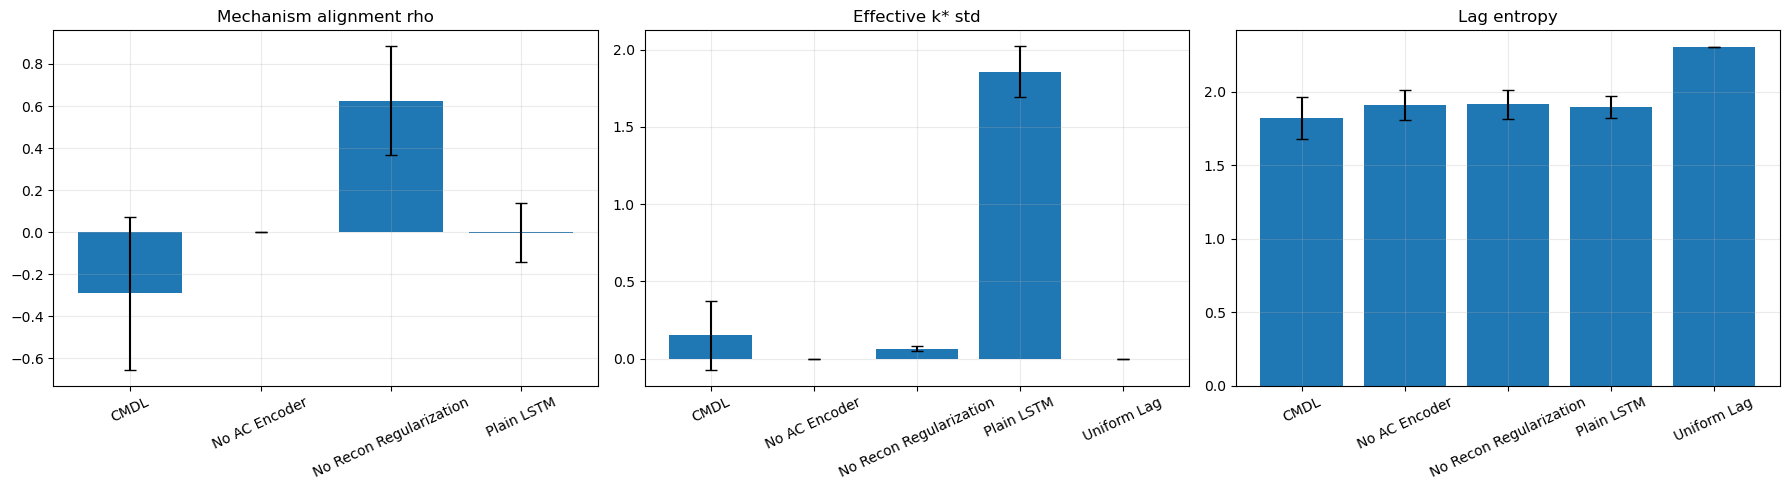

display_name,CMDL,No AC Encoder,No Recon Regularization,Plain LSTM,Uniform Lag
seed,,,,,
0,-0.225089,0.0,0.888979,-0.161988,NaN
1,0.036895,0.0,0.372636,0.104983,NaN
2,-0.681554,0.0,0.612765,0.046337,NaN


,display_name,rho_dominant_sign,rho_all_same_sign,rho_sign_consistency_share,rho_positive_seed_share,rho_negative_seed_share,mean_rho,mean_abs_rho,mean_kstar_std,mean_entropy,mean_test_r2
2,No Recon Regularization,positive,True,1.000000,1.000000,0.000000,0.624793,0.624793,6.421177e-02,1.913915,0.049896
0,CMDL,negative,False,0.666667,0.333333,0.666667,-0.289916,0.289916,1.524560e-01,1.823582,0.062804
3,Plain LSTM,positive,False,0.666667,0.666667,0.333333,-0.003556,0.003556,1.856049e+00,1.895777,0.099044
1,No AC Encoder,mixed,False,0.000000,0.000000,0.000000,0.000000,0.000000,3.042560e-07,1.910706,0.051759
4,Uniform Lag,none,False,NaN,NaN,NaN,NaN,NaN,0.000000e+00,2.302585,0.085656


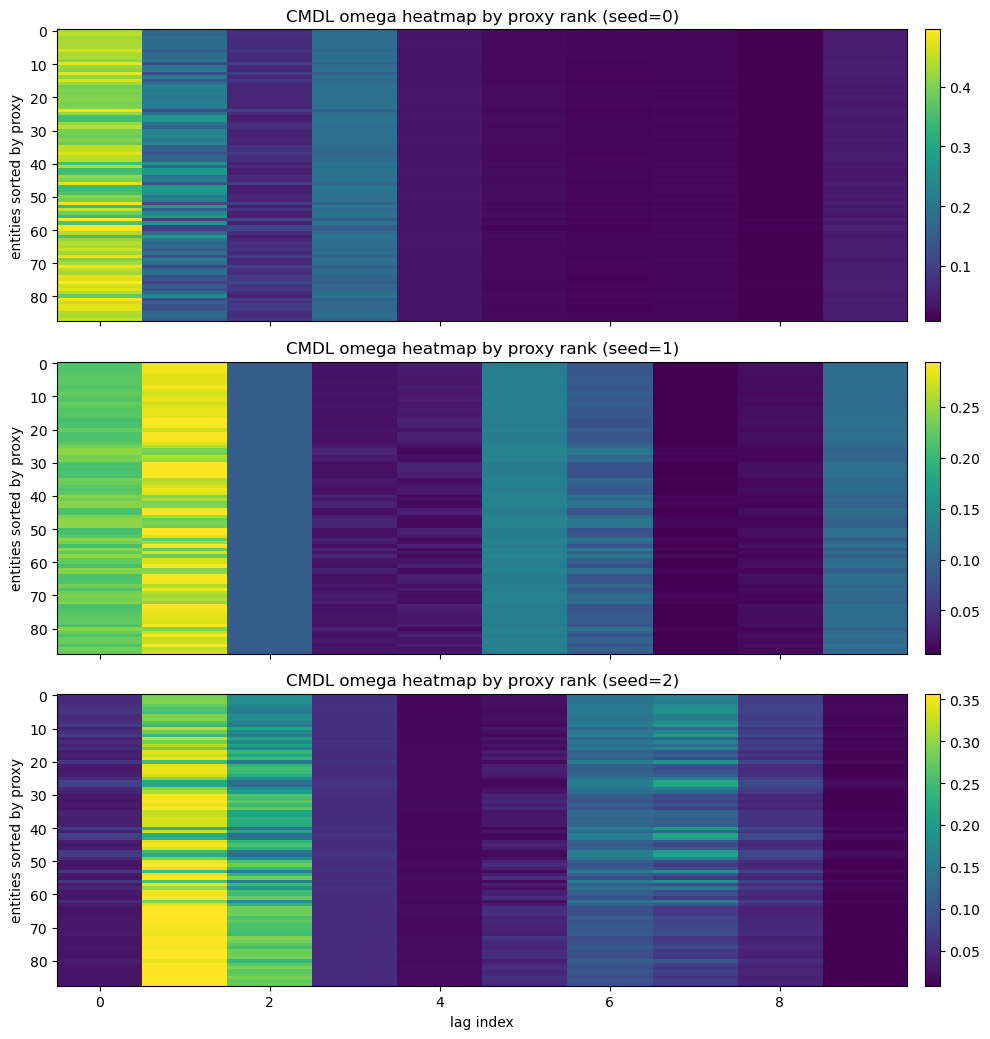

Saved formal mechanism plots to C:\DevSpace\PyDevspace\CMDL\outputs\notebook_economics\formal_mechanism_ctfp_effective_labor_aware\comparison_plots\formal_mechanism_summary.png and C:\DevSpace\PyDevspace\CMDL\outputs\notebook_economics\formal_mechanism_ctfp_effective_labor_aware\comparison_plots\formal_mechanism_omega_heatmaps.png


In [38]:
if formal_mechanism_summary.empty:
    print("No formal mechanism results found; skipping plots.")
else:
    plot_frame = formal_mechanism_summary.copy()
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    metric_specs = [
        ("test_effective_kstar_proxy_spearman_rho_mean", "test_effective_kstar_proxy_spearman_rho_std", "Mechanism alignment rho"),
        ("test_effective_kstar_std_mean", "test_effective_kstar_std_std", "Effective k* std"),
        ("test_effective_lag_entropy_mean_mean", "test_effective_lag_entropy_mean_std", "Lag entropy"),
    ]
    for axis, (mean_col, std_col, title) in zip(axes, metric_specs):
        axis.bar(plot_frame["display_name"], plot_frame[mean_col], yerr=plot_frame[std_col].fillna(0.0), capsize=4)
        axis.set_title(title)
        axis.tick_params(axis="x", rotation=25)
        axis.grid(alpha=0.25)
    fig.tight_layout()
    formal_mechanism_plot_path = FORMAL_MECHANISM_PLOTS_DIR / "formal_mechanism_summary.png"
    fig.savefig(formal_mechanism_plot_path, dpi=160, bbox_inches="tight")
    display(fig)
    plt.close(fig)

    sign_frame = formal_mechanism_comparison[["display_name", "seed", "test_effective_kstar_proxy_spearman_rho"]].copy()
    sign_pivot = sign_frame.pivot(index="seed", columns="display_name", values="test_effective_kstar_proxy_spearman_rho")
    display(sign_pivot)

    criteria_rows = []
    for _, row in formal_mechanism_summary.iterrows():
        mean_rho = row["test_effective_kstar_proxy_spearman_rho_mean"]
        criteria_rows.append(
            {
                "display_name": row["display_name"],
                "rho_dominant_sign": row["rho_dominant_sign"],
                "rho_all_same_sign": row["rho_all_same_sign"],
                "rho_sign_consistency_share": row["rho_sign_consistency_share"],
                "rho_positive_seed_share": row["rho_positive_seed_share"],
                "rho_negative_seed_share": row["rho_negative_seed_share"],
                "mean_rho": mean_rho,
                "mean_abs_rho": abs(mean_rho) if pd.notna(mean_rho) else np.nan,
                "mean_kstar_std": row["test_effective_kstar_std_mean"],
                "mean_entropy": row["test_effective_lag_entropy_mean_mean"],
                "mean_test_r2": row["test_r2_mean"],
            }
        )
    formal_mechanism_criteria = pd.DataFrame(criteria_rows).sort_values(
        ["rho_all_same_sign", "rho_sign_consistency_share", "mean_abs_rho", "mean_kstar_std"],
        ascending=[False, False, False, False],
        na_position="last",
    )
    formal_mechanism_criteria.to_csv(FORMAL_MECHANISM_COMPARISON_DIR / "formal_mechanism_criteria.csv", index=False)
    display(formal_mechanism_criteria)

    omega_frames = []
    for seed in FORMAL_MECHANISM_SEEDS:
        prediction_path = FORMAL_MECHANISM_CMDL_DIR / f"formal_mechanism_cmdl_seed{seed}" / "predictions.csv"
        if not prediction_path.exists():
            continue
        frame = pd.read_csv(prediction_path)
        omega_columns = sorted(
            [
                column
                for column in frame.columns
                if column.startswith("omega_") and column.split("_")[1].isdigit()
            ],
            key=lambda name: int(name.split("_")[1]),
        )
        entity_frame = frame.groupby("entity_code", as_index=False)[omega_columns].first()
        proxy_by_entity = frame.groupby("entity_code", as_index=False)["proxy_1_true"].first()
        entity_frame = entity_frame.merge(proxy_by_entity, on="entity_code", how="left")
        entity_frame = entity_frame.sort_values("proxy_1_true").reset_index(drop=True)
        omega_frames.append((seed, entity_frame[omega_columns].to_numpy(dtype=float)))

    if omega_frames:
        fig, axes = plt.subplots(len(omega_frames), 1, figsize=(10, 3.5 * len(omega_frames)), sharex=True)
        if len(omega_frames) == 1:
            axes = [axes]
        for axis, (seed, omega_matrix) in zip(axes, omega_frames):
            image = axis.imshow(omega_matrix, aspect="auto", cmap="viridis")
            axis.set_title(f"CMDL omega heatmap by proxy rank (seed={seed})")
            axis.set_ylabel("entities sorted by proxy")
            fig.colorbar(image, ax=axis, fraction=0.020, pad=0.02)
        axes[-1].set_xlabel("lag index")
        fig.tight_layout()
        formal_mechanism_heatmap_path = FORMAL_MECHANISM_PLOTS_DIR / "formal_mechanism_omega_heatmaps.png"
        fig.savefig(formal_mechanism_heatmap_path, dpi=160, bbox_inches="tight")
        display(fig)
        plt.close(fig)
        print(f"Saved formal mechanism plots to {formal_mechanism_plot_path} and {formal_mechanism_heatmap_path}")
    else:
        print(f"Saved formal mechanism plot to {formal_mechanism_plot_path}")

## Audit Update: Current Economics Status / 审计更新：当前经济领域结论

This subsection records the current economics conclusion after the matched-init repair for the no_recon_regularization control.
本节记录修复 no_recon_regularization 的 matched-init 对照之后，economics 当前最干净的结论。

- Screening result: effective_labor_aware remains the strongest economics contract for ctfp, so it stays as the formal target.
- Clean causal update: the earlier No Recon Regularization advantage is not valid. Once the control is rerun with matched initialization on economics_cleaned_long_v2.csv, repaired no_recon almost collapses onto CMDL.
- What is currently supported: removing the AC encoder collapses effective k* variability to nearly zero, and forcing uniform lag fixes entropy at log(10) with effective k* std also at zero. The heterogeneity machinery is active.
- What is not yet supported: CMDL still does not beat the plain LSTM on test $R^2$, and the sign of the k*-proxy alignment is not stable enough to support a strong mechanism claim on economics.
- Working verdict: AC-GATE is not disproved, but the economics evidence is still too weak to treat it as strongly established.

In [42]:
from pathlib import Path
import importlib

import pandas as pd

from evaluation import economics_comparison as economics_comparison_module

economics_comparison_module = importlib.reload(economics_comparison_module)
build_economics_comparison = economics_comparison_module.build_economics_comparison

if "repo_root" not in globals():
    current = Path.cwd().resolve()
    repo_root = next(
        (
            path
            for path in [current, *current.parents]
            if (path / "config").exists() and (path / "data").exists() and (path / "experiments").exists()
        ),
        None,
    )
    if repo_root is None:
        raise RuntimeError(f"Could not find repo root from {current}")

formal_original_root = repo_root / "outputs" / "notebook_economics" / "formal_mechanism_ctfp_effective_labor_aware"
formal_repaired_root = repo_root / "outputs" / "notebook_economics" / "formal_mechanism_ctfp_effective_labor_aware_matched_init"
formal_audit_dir = formal_original_root / "comparison"
formal_audit_dir.mkdir(parents=True, exist_ok=True)

formal_original_comparison = build_economics_comparison(
    cmdl_root=formal_original_root / "cmdl",
    baseline_root=formal_original_root / "plain_lstm",
    ablation_root=formal_original_root / "ablation",
)
formal_repaired_comparison = build_economics_comparison(
    ablation_root=formal_repaired_root / "ablation",
)

for frame in [formal_original_comparison, formal_repaired_comparison]:
    for column in ["matched_init_to_full_cmdl", "causal_ablation_validity"]:
        if column not in frame.columns:
            frame[column] = None

metric_columns = [
    "seed",
    "test_r2",
    "test_proxy_signal_r2",
    "test_effective_kstar_proxy_spearman_rho",
    "test_effective_kstar_std",
    "test_effective_lag_entropy_mean",
]

cmdl_audit = formal_original_comparison.loc[
    formal_original_comparison["family"] == "cmdl",
    metric_columns,
].copy()
cmdl_audit = cmdl_audit.rename(
    columns={column: f"{column}_cmdl" for column in metric_columns if column != "seed"}
)

old_no_recon_audit = formal_original_comparison.loc[
    formal_original_comparison["variant"] == "no_recon_regularization",
    metric_columns,
].copy()
old_no_recon_audit = old_no_recon_audit.rename(
    columns={column: f"{column}_old_no_recon" for column in metric_columns if column != "seed"}
)

new_no_recon_audit = formal_repaired_comparison.loc[
    formal_repaired_comparison["variant"] == "no_recon_regularization",
    metric_columns + ["matched_init_to_full_cmdl", "causal_ablation_validity"],
].copy()
new_no_recon_audit = new_no_recon_audit.rename(
    columns={column: f"{column}_matched_no_recon" for column in metric_columns if column != "seed"}
)

formal_mechanism_repaired_ablation_audit = (
    cmdl_audit
    .merge(old_no_recon_audit, on="seed", how="inner")
    .merge(new_no_recon_audit, on="seed", how="inner")
)
formal_mechanism_repaired_ablation_audit["delta_r2_old_minus_cmdl"] = (
    formal_mechanism_repaired_ablation_audit["test_r2_old_no_recon"]
    - formal_mechanism_repaired_ablation_audit["test_r2_cmdl"]
)
formal_mechanism_repaired_ablation_audit["delta_r2_matched_minus_cmdl"] = (
    formal_mechanism_repaired_ablation_audit["test_r2_matched_no_recon"]
    - formal_mechanism_repaired_ablation_audit["test_r2_cmdl"]
)
formal_mechanism_repaired_ablation_audit["delta_rho_old_minus_cmdl"] = (
    formal_mechanism_repaired_ablation_audit["test_effective_kstar_proxy_spearman_rho_old_no_recon"]
    - formal_mechanism_repaired_ablation_audit["test_effective_kstar_proxy_spearman_rho_cmdl"]
)
formal_mechanism_repaired_ablation_audit["delta_rho_matched_minus_cmdl"] = (
    formal_mechanism_repaired_ablation_audit["test_effective_kstar_proxy_spearman_rho_matched_no_recon"]
    - formal_mechanism_repaired_ablation_audit["test_effective_kstar_proxy_spearman_rho_cmdl"]
)

def summarize_run_set(label: str, frame: pd.DataFrame) -> dict[str, object]:
    return {
        "label": label,
        "mean_test_r2": float(frame["test_r2"].mean()),
        "mean_rho": float(frame["test_effective_kstar_proxy_spearman_rho"].mean()),
        "mean_kstar_std": float(frame["test_effective_kstar_std"].mean()),
        "mean_entropy": float(frame["test_effective_lag_entropy_mean"].mean()),
        "mean_proxy_signal_r2": float(frame["test_proxy_signal_r2"].mean()) if "test_proxy_signal_r2" in frame.columns else None,
    }

cmdl_rows = formal_original_comparison.loc[formal_original_comparison["family"] == "cmdl"].copy()
plain_lstm_rows = formal_original_comparison.loc[formal_original_comparison["family"] == "plain_lstm"].copy()
no_ac_rows = formal_original_comparison.loc[formal_original_comparison["variant"] == "no_ac_encoder"].copy()
uniform_rows = formal_original_comparison.loc[formal_original_comparison["variant"] == "uniform_lag"].copy()
old_no_recon_rows = formal_original_comparison.loc[
    formal_original_comparison["variant"] == "no_recon_regularization"
].copy()
matched_no_recon_rows = formal_repaired_comparison.loc[
    formal_repaired_comparison["variant"] == "no_recon_regularization"
].copy()

formal_mechanism_repaired_mean_summary = pd.DataFrame(
    [
        summarize_run_set("CMDL", cmdl_rows),
        summarize_run_set("Plain LSTM", plain_lstm_rows),
        summarize_run_set("No AC Encoder", no_ac_rows),
        summarize_run_set("Uniform Lag", uniform_rows),
        summarize_run_set("Old No Recon", old_no_recon_rows),
        summarize_run_set("Matched-init No Recon", matched_no_recon_rows),
    ]
)

cmdl_mean = formal_mechanism_repaired_mean_summary.loc[
    formal_mechanism_repaired_mean_summary["label"] == "CMDL"
].iloc[0]
plain_lstm_mean = formal_mechanism_repaired_mean_summary.loc[
    formal_mechanism_repaired_mean_summary["label"] == "Plain LSTM"
].iloc[0]
matched_no_recon_mean = formal_mechanism_repaired_mean_summary.loc[
    formal_mechanism_repaired_mean_summary["label"] == "Matched-init No Recon"
].iloc[0]
no_ac_mean = formal_mechanism_repaired_mean_summary.loc[
    formal_mechanism_repaired_mean_summary["label"] == "No AC Encoder"
].iloc[0]
uniform_mean = formal_mechanism_repaired_mean_summary.loc[
    formal_mechanism_repaired_mean_summary["label"] == "Uniform Lag"
].iloc[0]

current_result_rows: list[dict[str, object]] = []
if "phase_b_comparison" in globals() and isinstance(phase_b_comparison, pd.DataFrame) and not phase_b_comparison.empty:
    phase_b_cmdl_rows = phase_b_comparison.loc[phase_b_comparison["family"] == "cmdl"].copy()
    if not phase_b_cmdl_rows.empty:
        phase_b_best_forecast = phase_b_cmdl_rows.sort_values(
            ["test_r2", "test_effective_kstar_proxy_spearman_rho"],
            ascending=[False, False],
            na_position="last",
        ).iloc[0]
        current_result_rows.append(
            {
                "stage": "screening",
                "question": "Which contract currently wins pure forecast screening?",
                "result": f"{phase_b_best_forecast['target_column']} + {phase_b_best_forecast['feature_bundle']}",
                "evidence": (
                    f"Best Phase B CMDL row by test_r2; test_r2={phase_b_best_forecast['test_r2']:.4f}, "
                    f"rho={phase_b_best_forecast['test_effective_kstar_proxy_spearman_rho']:.4f}."
                ),
            }
        )

current_result_rows.extend(
    [
        {
            "stage": "screening",
            "question": "Which contract remains the main AC-GATE formal target?",
            "result": f"{FORMAL_MECHANISM_TARGET} + {FORMAL_MECHANISM_FEATURE_BUNDLE}",
            "evidence": "This contract keeps the effective-labor anchor and exposes the AC-GATE mechanism question most directly, even if another row has better raw forecast metrics.",
        },
        {
            "stage": "formal",
            "question": "Does economics strongly establish AC-GATE today?",
            "result": "No, not yet",
            "evidence": (
                f"CMDL mean test_r2={cmdl_mean['mean_test_r2']:.4f}, while Plain LSTM mean test_r2={plain_lstm_mean['mean_test_r2']:.4f}; "
                f"CMDL mean rho={cmdl_mean['mean_rho']:.4f} and its sign is still not stable across seeds."
            ),
        },
        {
            "stage": "formal",
            "question": "Was the old No Recon advantage causal?",
            "result": "No",
            "evidence": (
                f"After the matched-init rerun, repaired no_recon mean test_r2={matched_no_recon_mean['mean_test_r2']:.4f} "
                f"vs CMDL {cmdl_mean['mean_test_r2']:.4f}, and repaired mean rho={matched_no_recon_mean['mean_rho']:.4f} "
                f"vs CMDL {cmdl_mean['mean_rho']:.4f}; they nearly collapse onto each other."
            ),
        },
        {
            "stage": "formal",
            "question": "Does the heterogeneity machinery still matter?",
            "result": "Yes",
            "evidence": (
                f"No AC Encoder drives mean effective k* std down to {no_ac_mean['mean_kstar_std']:.6f}, "
                f"and Uniform Lag fixes mean entropy at {uniform_mean['mean_entropy']:.4f} with mean effective k* std={uniform_mean['mean_kstar_std']:.6f}."
            ),
        },
        {
            "stage": "decision",
            "question": "Current economics verdict",
            "result": "Weak support for the architecture, no clean support yet for the reconstruction branch",
            "evidence": "The next step should be controlled optimization-path repair, not a new proxy search or a stronger claim.",
        },
    ]
)

economics_current_result_log = pd.DataFrame(current_result_rows)

formal_mechanism_repaired_ablation_audit.to_csv(
    formal_audit_dir / "formal_mechanism_repaired_no_recon_vs_cmdl.csv",
    index=False,
)
formal_mechanism_repaired_mean_summary.to_csv(
    formal_audit_dir / "formal_mechanism_repaired_no_recon_mean_summary.csv",
    index=False,
)
economics_current_result_log.to_csv(
    formal_audit_dir / "economics_current_result_log.csv",
    index=False,
)

display(economics_current_result_log)
display(formal_mechanism_repaired_mean_summary)
display(formal_mechanism_repaired_ablation_audit)

,stage,question,result,evidence
0,screening,Which contract currently wins pure forecast sc...,rtfpna + minimal,Best Phase B CMDL row by test_r2; test_r2=0.05...
1,screening,Which contract remains the main AC-GATE formal...,ctfp + effective_labor_aware,This contract keeps the effective-labor anchor...
2,formal,Does economics strongly establish AC-GATE today?,"No, not yet","CMDL mean test_r2=0.0628, while Plain LSTM mea..."
3,formal,Was the old No Recon advantage causal?,No,"After the matched-init rerun, repaired no_reco..."
4,formal,Does the heterogeneity machinery still matter?,Yes,No AC Encoder drives mean effective k* std dow...
5,decision,Current economics verdict,"Weak support for the architecture, no clean su...",The next step should be controlled optimizatio...


,label,mean_test_r2,mean_rho,mean_kstar_std,mean_entropy,mean_proxy_signal_r2
0,CMDL,0.062804,-0.289916,1.524560e-01,1.823582,0.246799
1,Plain LSTM,0.099044,-0.003556,1.856049e+00,1.895777,NaN
2,No AC Encoder,0.051759,0.000000,3.042560e-07,1.910706,NaN
3,Uniform Lag,0.085656,NaN,0.000000e+00,2.302585,0.242595
4,Old No Recon,0.049896,0.624793,6.421177e-02,1.913915,0.314550
5,Matched-init No Recon,0.061623,-0.292487,1.513779e-01,1.823914,0.247328


,seed,test_r2_cmdl,test_proxy_signal_r2_cmdl,test_effective_kstar_proxy_spearman_rho_cmdl,test_effective_kstar_std_cmdl,test_effective_lag_entropy_mean_cmdl,test_r2_old_no_recon,test_proxy_signal_r2_old_no_recon,test_effective_kstar_proxy_spearman_rho_old_no_recon,test_effective_kstar_std_old_no_recon,...,test_proxy_signal_r2_matched_no_recon,test_effective_kstar_proxy_spearman_rho_matched_no_recon,test_effective_kstar_std_matched_no_recon,test_effective_lag_entropy_mean_matched_no_recon,matched_init_to_full_cmdl,causal_ablation_validity,delta_r2_old_minus_cmdl,delta_r2_matched_minus_cmdl,delta_rho_old_minus_cmdl,delta_rho_matched_minus_cmdl
0,0,0.046185,0.202664,-0.225089,0.040269,1.662403,0.032997,0.382450,0.888979,0.046057,...,0.202668,-0.225089,0.040267,1.662415,True,matched_init_effective_lambda_only,-0.013188,1.014634e-06,1.114068,0.000000
1,1,0.072451,0.219966,0.036895,0.007622,1.931944,0.066536,0.251640,0.372636,0.067116,...,0.219964,0.035768,0.007620,1.931945,True,matched_init_effective_lambda_only,-0.005915,-4.115518e-07,0.335740,-0.001127
2,2,0.069775,0.317766,-0.681554,0.409477,1.876398,0.050156,0.309562,0.612765,0.079462,...,0.319352,-0.688141,0.406247,1.877382,True,matched_init_effective_lambda_only,-0.019619,-3.540901e-03,1.294319,-0.006587


## Controlled Solution Search / 受控解决方案搜索

The next phase has only one goal: turn the economics result from a descriptive implementation into a stronger AC-GATE claim.
下一阶段只有一个目标：把 economics 的结果从“有实现、有现象”推进到“对 AC-GATE 有更强证明力”的结论。

The search should stay causal and controlled:
搜索必须保持因果上干净，而不是继续混入新的变量。

1. First repair the optimization path: test whether global gradient clipping is hiding the effect of reconstruction regularization.
2. Then align the evaluation contract: separate the all-proxy reconstruction target from the single-anchor mechanism metric.
3. Only if the repaired controls still show tension should the reconstruction objective itself be changed.

The objective is not to maximize one number at any cost, but to identify the smallest change that can make the AC-GATE mechanism claim hold on economics data.

In [40]:
economics_solution_hypotheses = pd.DataFrame(
    [
        {
            "priority": 1,
            "next_experiment": "split_clip control",
            "minimal_change": "Add clip_mode with global_clip versus split_clip in the economics runners",
            "why_this_is_next": "After matched-init repair, the remaining path from lambda_r to the task update is mainly global gradient clipping.",
            "success_criterion": "CMDL versus matched-init no_recon becomes either even closer or the residual gap becomes cleanly attributable to clipping.",
            "if_it_fails": "Move to anchor/evaluation mismatch rather than claiming reconstruction regularization is harmful.",
        },
        {
            "priority": 2,
            "next_experiment": "anchor-aligned diagnostics",
            "minimal_change": "Log anchor_proxy_name, anchor_sign_convention, anchor-only readout quality, and all-proxy readout quality",
            "why_this_is_next": "Training currently reconstructs four proxies, but the mechanism table still judges success with a single anchor proxy.",
            "success_criterion": "The notebook can distinguish anchor improvement, auxiliary-proxy improvement, and mixed cases instead of compressing them into one rho.",
            "if_it_fails": "Do not change the objective yet; first make the failure mode observable.",
        },
        {
            "priority": 3,
            "next_experiment": "anchor-weighted reconstruction",
            "minimal_change": "Keep the same architecture and data contract, but give the effective-labor anchor a larger reconstruction weight",
            "why_this_is_next": "If the repaired controls still show tension, the current all-proxy objective may be too diffuse relative to the mechanism anchor.",
            "success_criterion": "CMDL improves anchor-aligned diagnostics without collapsing forecast quality or heterogeneity structure.",
            "if_it_fails": "Escalate to anchor-only reconstruction instead of expanding the proxy bundle again.",
        },
        {
            "priority": 4,
            "next_experiment": "anchor-only reconstruction",
            "minimal_change": "Train the reconstruction loss only on the effective-labor anchor while keeping auxiliary proxies as inputs or diagnostics",
            "why_this_is_next": "This is the cleanest way to test whether auxiliary proxies are diluting the mechanism objective.",
            "success_criterion": "Sign consistency and anchor readout improve while the AC encoder and learned lag effects remain active.",
            "if_it_fails": "The economics claim should likely be downgraded to weak real-data support instead of strong validation.",
        },
        {
            "priority": 5,
            "next_experiment": "two-head reconstruction",
            "minimal_change": "Use separate anchor and auxiliary reconstruction heads after the simpler controls above",
            "why_this_is_next": "This is only justified if the previous controls confirm a real objective conflict rather than an optimization artifact.",
            "success_criterion": "The anchor head improves the mechanism claim without losing the auxiliary information carried by the richer proxy bundle.",
            "if_it_fails": "Stop escalating complexity and treat economics as a feasibility domain rather than the main proof domain.",
        },
    ]
)

economics_solution_hypotheses.to_csv(
    formal_audit_dir / "economics_solution_hypotheses.csv",
    index=False,
)

display(economics_solution_hypotheses)

,priority,next_experiment,minimal_change,why_this_is_next,success_criterion,if_it_fails
0,1,split_clip control,Add clip_mode with global_clip versus split_cl...,"After matched-init repair, the remaining path ...",CMDL versus matched-init no_recon becomes eith...,Move to anchor/evaluation mismatch rather than...
1,2,anchor-aligned diagnostics,"Log anchor_proxy_name, anchor_sign_convention,...","Training currently reconstructs four proxies, ...",The notebook can distinguish anchor improvemen...,Do not change the objective yet; first make th...
2,3,anchor-weighted reconstruction,"Keep the same architecture and data contract, ...","If the repaired controls still show tension, t...",CMDL improves anchor-aligned diagnostics witho...,Escalate to anchor-only reconstruction instead...
3,4,anchor-only reconstruction,Train the reconstruction loss only on the effe...,This is the cleanest way to test whether auxil...,Sign consistency and anchor readout improve wh...,The economics claim should likely be downgrade...
4,5,two-head reconstruction,Use separate anchor and auxiliary reconstructi...,This is only justified if the previous control...,The anchor head improves the mechanism claim w...,Stop escalating complexity and treat economics...


## Phase4/Phase6 Upgraded Formal Validation / 改进后正式验证

This section runs a focused non-smoke validation after the Phase4/Phase6 implementation. It keeps the formal economics contract (`ctfp` + `effective_labor_aware`) and writes a separate output root so the older formal audit remains reproducible.

本节在 Phase4/Phase6 改造后执行一次聚焦的非 smoke 正式验证。实验仍使用 economics 正式机制契约（`ctfp` + `effective_labor_aware`），并写入独立输出目录，避免覆盖旧 formal audit。

In [ ]:
from argparse import Namespace
from pathlib import Path
import importlib
import sys

import pandas as pd
from IPython.display import display

current = Path.cwd().resolve()
repo_root = next(
    (
        path
        for path in [current, *current.parents]
        if (path / "config").exists() and (path / "data").exists() and (path / "experiments").exists()
    ),
    None,
)
if repo_root is None:
    raise RuntimeError(f"Could not find repo root from {current}")
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from baselines import panel_ols as panel_ols_module

panel_ols_module = importlib.reload(panel_ols_module)

from baselines import grouped_ardl as grouped_ardl_module
from evaluation import economics_comparison as economics_comparison_module
from experiments import run_economics as run_economics_module
from experiments import run_economics_ablation as run_economics_ablation_module
from experiments import run_economics_grouped_ardl as run_economics_grouped_ardl_module
from experiments import run_economics_lstm_baseline as run_economics_lstm_baseline_module

grouped_ardl_module = importlib.reload(grouped_ardl_module)
economics_comparison_module = importlib.reload(economics_comparison_module)
run_economics_module = importlib.reload(run_economics_module)
run_economics_ablation_module = importlib.reload(run_economics_ablation_module)
run_economics_grouped_ardl_module = importlib.reload(run_economics_grouped_ardl_module)
run_economics_lstm_baseline_module = importlib.reload(run_economics_lstm_baseline_module)

build_economics_comparison = economics_comparison_module.build_economics_comparison
build_task_table = economics_comparison_module.build_task_table
build_interpretability_table = economics_comparison_module.build_interpretability_table
build_per_proxy_alignment_table = economics_comparison_module.build_per_proxy_alignment_table
build_per_proxy_audit_summary_table = economics_comparison_module.build_per_proxy_audit_summary_table
build_grouped_ardl_lag_trend_table = economics_comparison_module.build_grouped_ardl_lag_trend_table
build_mechanism_summary_table = economics_comparison_module.build_mechanism_summary_table
build_mechanism_result_log = economics_comparison_module.build_mechanism_result_log
run_cmdl_experiment = run_economics_module.run_experiment
run_baseline_experiment = run_economics_lstm_baseline_module.run_experiment
run_grouped_ardl_experiment = run_economics_grouped_ardl_module.run_experiment
run_ablation_suite = run_economics_ablation_module.run_suite

PHASE46_ECONOMICS_OUTPUT_ROOT = repo_root / "outputs" / "notebook_economics" / "phase46_formal_validation"
PHASE46_ECONOMICS_CMDL_DIR = PHASE46_ECONOMICS_OUTPUT_ROOT / "cmdl"
PHASE46_ECONOMICS_BASELINE_DIR = PHASE46_ECONOMICS_OUTPUT_ROOT / "plain_lstm"
PHASE46_ECONOMICS_GROUPED_ARDL_DIR = PHASE46_ECONOMICS_OUTPUT_ROOT / "grouped_ardl"
PHASE46_ECONOMICS_ABLATION_DIR = PHASE46_ECONOMICS_OUTPUT_ROOT / "ablation"
PHASE46_ECONOMICS_COMPARISON_DIR = PHASE46_ECONOMICS_OUTPUT_ROOT / "comparison"
PHASE46_ECONOMICS_SEEDS = [0, 1, 2]
PHASE46_ECONOMICS_PRESET = {"epochs": 30, "patience": 8, "log_every": 5}
PHASE46_ECONOMICS_COMMON_ARGS = {
    "csv_path": str(repo_root / "data" / "economics" / "processed" / "economics_cleaned_long_v2.csv"),
    "year_start": 1980,
    "year_end": 2023,
    "train_end_year": 2007,
    "val_end_year": 2013,
    "target_column": "ctfp",
    "feature_bundle": "effective_labor_aware",
    "max_missing_share": 0.15,
    "lr": 1e-3,
    "lambda_r": 0.1,
    "temperature": 1.0,
    "omega_transform": "softmax",
    "lambda_omega_entropy": 0.0,
    "omega_entropy_min": None,
    "omega_entropy_max": None,
    "lambda_z_anchor": 0.0,
    "z_anchor_target_sign": 1.0,
    "lag_bias_strength": 1.0,
    "grad_clip": 1.0,
    "grad_clip_mode": "split",
    "recon_loss_mode": "anchor_weighted",
    "anchor_recon_weight": 2.0,
    "reconstruction_detach": False,
    "device": "auto",
    "disable_mlflow": True,
    "smoke": False,
}

for path in [
    PHASE46_ECONOMICS_OUTPUT_ROOT,
    PHASE46_ECONOMICS_CMDL_DIR,
    PHASE46_ECONOMICS_BASELINE_DIR,
    PHASE46_ECONOMICS_GROUPED_ARDL_DIR,
    PHASE46_ECONOMICS_ABLATION_DIR,
    PHASE46_ECONOMICS_COMPARISON_DIR,
]:
    path.mkdir(parents=True, exist_ok=True)

phase46_economics_settings = pd.Series(
    {
        "output_root": PHASE46_ECONOMICS_OUTPUT_ROOT,
        "seeds": PHASE46_ECONOMICS_SEEDS,
        **PHASE46_ECONOMICS_PRESET,
        **PHASE46_ECONOMICS_COMMON_ARGS,
    },
    name="value",
).to_frame()
display(phase46_economics_settings)

,value
output_root,C:\DevSpace\PyDevspace\CMDL\outputs\notebook_e...
seeds,"[0, 1, 2]"
epochs,30
patience,8
log_every,5
csv_path,C:\DevSpace\PyDevspace\CMDL\data\economics\pro...
year_start,1980
year_end,2023
train_end_year,2007
val_end_year,2013


In [ ]:
import numpy as np

phase46_economics_cmdl_summaries: list[dict[str, object]] = []
phase46_economics_baseline_summaries: list[dict[str, object]] = []
phase46_economics_grouped_ardl_summaries: list[dict[str, object]] = []

for seed in PHASE46_ECONOMICS_SEEDS:
    shared_args = {
        **PHASE46_ECONOMICS_COMMON_ARGS,
        **PHASE46_ECONOMICS_PRESET,
        "seed": seed,
    }

    cmdl_args = Namespace(
        **shared_args,
        output_dir=str(PHASE46_ECONOMICS_CMDL_DIR),
        experiment_name=f"phase46_economics_cmdl_seed{seed}",
    )
    cmdl_summary = run_cmdl_experiment(cmdl_args)
    phase46_economics_cmdl_summaries.append(cmdl_summary)
    print(
        f"CMDL seed={seed} test_r2={cmdl_summary['metrics']['test']['r2']:.4f} "
        f"adjusted_rho={cmdl_summary['metrics']['test'].get('kstar_proxy_spearman_adjusted_rho', np.nan):.4f} "
        f"lag_range={cmdl_summary['metrics']['test'].get('lag_gate_sensitivity_range', np.nan):.4f}"
    )

    baseline_args = Namespace(
        **shared_args,
        output_dir=str(PHASE46_ECONOMICS_BASELINE_DIR),
        experiment_name=f"phase46_economics_lstm_seed{seed}",
    )
    baseline_summary = run_baseline_experiment(baseline_args)
    phase46_economics_baseline_summaries.append(baseline_summary)
    print(
        f"Plain LSTM seed={seed} test_r2={baseline_summary['metrics']['test']['r2']:.4f} "
        f"posthoc_adjusted_rho={baseline_summary['metrics']['test'].get('posthoc_kstar_proxy_spearman_adjusted_rho', np.nan):.4f}"
    )

    grouped_ardl_args = Namespace(
        **shared_args,
        output_dir=str(PHASE46_ECONOMICS_GROUPED_ARDL_DIR),
        experiment_name=f"phase46_economics_grouped_ardl_seed{seed}",
    )
    grouped_ardl_summary = run_grouped_ardl_experiment(grouped_ardl_args)
    phase46_economics_grouped_ardl_summaries.append(grouped_ardl_summary)
    print(
        f"Grouped ARDL seed={seed} test_r2={grouped_ardl_summary['metrics']['test']['r2']:.4f} "
        f"effective_lag_mean={grouped_ardl_summary['metrics']['test'].get('effective_lag_mean', np.nan):.4f}"
    )

phase46_economics_ablation_args = Namespace(
    **PHASE46_ECONOMICS_COMMON_ARGS,
    **PHASE46_ECONOMICS_PRESET,
    seeds=PHASE46_ECONOMICS_SEEDS,
    variant="all",
    output_dir=str(PHASE46_ECONOMICS_ABLATION_DIR),
    experiment_prefix="phase46_economics_ablation",
)
phase46_economics_ablation_summary, phase46_economics_ablation_aggregated = run_ablation_suite(
    phase46_economics_ablation_args
)
if not phase46_economics_ablation_aggregated.empty:
    display(phase46_economics_ablation_aggregated)

[phase46_economics_cmdl_seed0] epoch=001 train_total=1.9567 val_task=2.9859 val_r2=-0.0789 val_proxy_r2=-0.3824
[phase46_economics_cmdl_seed0] epoch=005 train_total=0.9501 val_task=2.6982 val_r2=0.0334 val_proxy_r2=-0.3596
[phase46_economics_cmdl_seed0] epoch=010 train_total=0.6928 val_task=2.4848 val_r2=0.1126 val_proxy_r2=-0.3328
[phase46_economics_cmdl_seed0] epoch=015 train_total=0.5943 val_task=2.4590 val_r2=0.1161 val_proxy_r2=-0.3060
[phase46_economics_cmdl_seed0] epoch=020 train_total=0.5186 val_task=2.4850 val_r2=0.0937 val_proxy_r2=-0.2785
[phase46_economics_cmdl_seed0] epoch=025 train_total=0.4611 val_task=2.4668 val_r2=0.1020 val_proxy_r2=-0.2502
[phase46_economics_cmdl_seed0] early stopping at epoch 25
CMDL seed=0 test_r2=0.0445 adjusted_rho=-0.1590 lag_range=0.1046
[phase46_economics_lstm_seed0] epoch=001 train_task=1.1782 val_task=2.9468 val_mae=1.3153 val_r2=-0.0617
[phase46_economics_lstm_seed0] epoch=005 train_task=0.7118 val_task=2.7443 val_mae=1.2538 val_r2=0.0215
[

,variant,target_column,effective_lambda_r_mean,effective_lambda_r_std,matched_init_to_full_cmdl_mean,matched_init_to_full_cmdl_std,best_epoch_mean,best_epoch_std,best_val_task_loss_mean,best_val_task_loss_std,...,test_baseline_best_simple_r2_mean,test_baseline_best_simple_r2_std,test_r2_delta_vs_train_mean_mean,test_r2_delta_vs_train_mean_std,test_r2_delta_vs_entity_mean_mean,test_r2_delta_vs_entity_mean_std,test_r2_delta_vs_persistence_mean,test_r2_delta_vs_persistence_std,test_r2_delta_vs_panel_ols_mean,test_r2_delta_vs_panel_ols_std
0,no_ac_encoder,ctfp,0.0,NaN,0.0,NaN,11.0,NaN,2.540531,NaN,...,0.936833,NaN,0.086931,NaN,0.079904,NaN,-0.905181,NaN,0.010647,NaN
1,no_recon_regularization,ctfp,0.0,NaN,1.0,NaN,17.0,NaN,2.419961,NaN,...,0.936833,NaN,0.101600,NaN,0.094572,NaN,-0.890512,NaN,0.025315,NaN
2,uniform_lag,ctfp,0.1,NaN,0.0,NaN,23.0,NaN,2.502127,NaN,...,0.936833,NaN,0.163771,NaN,0.156743,NaN,-0.828341,NaN,0.087487,NaN


In [ ]:
phase46_economics_comparison = build_economics_comparison(
    cmdl_root=PHASE46_ECONOMICS_CMDL_DIR,
    baseline_root=PHASE46_ECONOMICS_BASELINE_DIR,
    ablation_root=PHASE46_ECONOMICS_ABLATION_DIR,
    grouped_ardl_root=PHASE46_ECONOMICS_GROUPED_ARDL_DIR,
)
phase46_economics_task_table = build_task_table(phase46_economics_comparison)
phase46_economics_interpretability_table = build_interpretability_table(phase46_economics_comparison)
phase46_economics_per_proxy = build_per_proxy_alignment_table(phase46_economics_comparison)
phase46_economics_per_proxy_audit_summary = build_per_proxy_audit_summary_table(phase46_economics_comparison)
phase46_economics_grouped_ardl_lag_trend = build_grouped_ardl_lag_trend_table(phase46_economics_comparison)
phase46_economics_mechanism_summary = build_mechanism_summary_table(phase46_economics_comparison)
phase46_economics_result_log = build_mechanism_result_log(phase46_economics_comparison)

phase46_economics_comparison.to_csv(PHASE46_ECONOMICS_COMPARISON_DIR / "phase46_economics_comparison.csv", index=False)
phase46_economics_task_table.to_csv(PHASE46_ECONOMICS_COMPARISON_DIR / "phase46_economics_task_table.csv", index=False)
phase46_economics_interpretability_table.to_csv(
    PHASE46_ECONOMICS_COMPARISON_DIR / "phase46_economics_interpretability_table.csv",
    index=False,
)
phase46_economics_per_proxy.to_csv(
    PHASE46_ECONOMICS_COMPARISON_DIR / "phase46_economics_per_proxy_adjusted_rho.csv",
    index=False,
)
phase46_economics_per_proxy_audit_summary.to_csv(
    PHASE46_ECONOMICS_COMPARISON_DIR / "phase46_economics_per_proxy_audit_summary.csv",
    index=False,
)
phase46_economics_grouped_ardl_lag_trend.to_csv(
    PHASE46_ECONOMICS_COMPARISON_DIR / "phase46_economics_grouped_ardl_lag_trend.csv",
    index=False,
)
phase46_economics_mechanism_summary.to_csv(
    PHASE46_ECONOMICS_COMPARISON_DIR / "phase46_economics_mechanism_summary.csv",
    index=False,
)
phase46_economics_result_log.to_csv(
    PHASE46_ECONOMICS_COMPARISON_DIR / "phase46_economics_result_log.csv",
    index=False,
)

phase46_task_columns = [
    "display_name",
    "variant",
    "seed",
    "test_r2",
    "test_baseline_persistence_r2",
    "test_baseline_panel_ols_r2",
    "test_baseline_grouped_ardl_r2",
    "test_baseline_best_simple_r2",
    "test_r2_delta_vs_persistence",
    "test_r2_delta_vs_panel_ols",
    "test_r2_delta_vs_grouped_ardl",
    "test_mae",
]
phase46_interp_columns = [
    "display_name",
    "variant",
    "seed",
    "anchor_proxy_name",
    "anchor_expected_sign",
    "test_effective_kstar_proxy_spearman_rho",
    "test_effective_kstar_proxy_spearman_adjusted_rho",
    "test_effective_kstar_proxy_mean_spearman_adjusted_rho",
    "test_effective_kstar_std",
    "test_effective_lag_entropy_mean",
    "test_effective_lag_top1_share",
    "test_z_std",
    "test_z_proxy_spearman_adjusted_rho",
    "test_z_anchor_adjusted_rho",
    "test_lag_gate_sensitivity_range",
    "test_proxy_signal_r2",
    "test_omega_entropy_penalty",
    "test_omega_entropy_band_violation_share",
    "test_z_anchor_loss",
    "omega_transform",
    "lambda_omega_entropy",
    "lambda_z_anchor",
    "grad_clip_mode",
    "recon_loss_mode",
    "anchor_recon_weight",
    "reconstruction_detach",
]
phase46_task_view = phase46_economics_task_table[[c for c in phase46_task_columns if c in phase46_economics_task_table.columns]]
phase46_interp_view = phase46_economics_interpretability_table[
    [c for c in phase46_interp_columns if c in phase46_economics_interpretability_table.columns]
]

print(f"phase46 economics rows = {len(phase46_economics_comparison)}")
display(phase46_task_view)
display(phase46_interp_view)
display(phase46_economics_per_proxy)
display(phase46_economics_per_proxy_audit_summary)
display(phase46_economics_grouped_ardl_lag_trend)
display(phase46_economics_mechanism_summary)
display(phase46_economics_result_log)

phase46 economics rows = 8


,display_name,variant,seed,test_r2,test_baseline_persistence_r2,test_baseline_panel_ols_r2,test_baseline_grouped_ardl_r2,test_baseline_best_simple_r2,test_r2_delta_vs_persistence,test_r2_delta_vs_panel_ols,test_r2_delta_vs_grouped_ardl,test_mae
0,Uniform Lag,uniform_lag,0,0.108492,0.936833,0.021006,-0.089107,0.936833,-0.828341,0.087487,0.197599,1.446173
1,No Recon Regularization,no_recon_regularization,0,0.046321,0.936833,0.021006,-0.089107,0.936833,-0.890512,0.025315,0.135428,1.485739
2,CMDL,None,0,0.044504,0.936833,0.021006,-0.089107,0.936833,-0.892330,0.023498,0.133611,1.487451
3,No AC Encoder,no_ac_encoder,0,0.031652,0.936833,0.021006,-0.089107,0.936833,-0.905181,0.010647,0.120759,1.499241
4,Plain LSTM,None,0,0.008364,0.936833,0.021006,-0.089107,0.936833,-0.928469,-0.012641,0.097471,1.504982
5,Grouped ARDL,None,0,-0.089107,NaN,NaN,None,NaN,NaN,NaN,None,1.567527
6,Grouped ARDL,None,1,-0.089107,NaN,NaN,None,NaN,NaN,NaN,None,1.567527
7,Grouped ARDL,None,2,-0.089107,NaN,NaN,None,NaN,NaN,NaN,None,1.567527


,display_name,variant,seed,anchor_proxy_name,anchor_expected_sign,test_effective_kstar_proxy_spearman_rho,test_effective_kstar_proxy_spearman_adjusted_rho,test_effective_kstar_proxy_mean_spearman_adjusted_rho,test_effective_kstar_std,test_effective_lag_entropy_mean,...,test_z_proxy_spearman_adjusted_rho,test_z_anchor_adjusted_rho,test_lag_gate_sensitivity_range,test_proxy_signal_r2,test_omega_entropy_penalty,test_omega_entropy_band_violation_share,test_z_anchor_loss,omega_transform,lambda_omega_entropy,lambda_z_anchor
0,CMDL,None,0,proxy_effective_labor_anchor,-1.0,0.158976,-0.158976,0.219665,0.033585,1.653976,...,0.158976,NaN,0.104592,0.203542,NaN,NaN,NaN,None,NaN,NaN
1,Plain LSTM,None,0,proxy_effective_labor_anchor,-1.0,-0.138049,0.138049,0.052311,1.950208,1.834022,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,NaN,NaN
2,No Recon Regularization,no_recon_regularization,0,proxy_effective_labor_anchor,-1.0,-0.219770,0.219770,0.574672,0.039514,1.663377,...,-0.223891,NaN,0.129077,0.203075,NaN,NaN,NaN,None,NaN,NaN
3,Uniform Lag,uniform_lag,0,proxy_effective_labor_anchor,-1.0,NaN,NaN,NaN,0.000000,2.302585,...,0.231306,NaN,0.132847,0.229173,NaN,NaN,NaN,None,NaN,NaN
4,Grouped ARDL,None,0,proxy_effective_labor_anchor,-1.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,softmax,0.0,0.0
5,Grouped ARDL,None,1,proxy_effective_labor_anchor,-1.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,softmax,0.0,0.0
6,Grouped ARDL,None,2,proxy_effective_labor_anchor,-1.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,softmax,0.0,0.0
7,No AC Encoder,no_ac_encoder,0,proxy_effective_labor_anchor,-1.0,NaN,NaN,NaN,0.000000,1.755515,...,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,None,NaN,NaN


,display_name,family,variant,seed,experiment,target_column,feature_bundle,anchor_proxy_name,anchor_expected_sign,proxy_name,adjusted_rho
0,CMDL,cmdl,None,0,phase46_economics_cmdl_seed0,ctfp,effective_labor_aware,proxy_effective_labor_anchor,-1.0,effective_labor_anchor,-0.158976
1,CMDL,cmdl,None,0,phase46_economics_cmdl_seed0,ctfp,effective_labor_aware,proxy_effective_labor_anchor,-1.0,employment_level,-0.139851
2,CMDL,cmdl,None,0,phase46_economics_cmdl_seed0,ctfp,effective_labor_aware,proxy_effective_labor_anchor,-1.0,hc_level,0.806418
3,CMDL,cmdl,None,0,phase46_economics_cmdl_seed0,ctfp,effective_labor_aware,proxy_effective_labor_anchor,-1.0,hc_trend,0.100807


,display_name,family,variant,target_column,feature_bundle,anchor_proxy_name,anchor_expected_sign,n_seeds,test_r2_mean,test_r2_std,...,test_omega_entropy_penalty_mean,test_omega_entropy_penalty_std,test_omega_entropy_band_violation_share_mean,test_omega_entropy_band_violation_share_std,test_z_anchor_loss_mean,test_z_anchor_loss_std,test_lag_gate_sensitivity_range_mean,test_lag_gate_sensitivity_range_std,test_proxy_signal_r2_mean,test_proxy_signal_r2_std
0,CMDL,cmdl,NaN,ctfp,effective_labor_aware,proxy_effective_labor_anchor,-1.0,1,0.044504,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.104592,NaN,0.203542,NaN
1,Grouped ARDL,grouped_ardl,NaN,ctfp,effective_labor_aware,proxy_effective_labor_anchor,-1.0,3,-0.089107,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,No AC Encoder,ablation,no_ac_encoder,ctfp,effective_labor_aware,proxy_effective_labor_anchor,-1.0,1,0.031652,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN
3,No Recon Regularization,ablation,no_recon_regularization,ctfp,effective_labor_aware,proxy_effective_labor_anchor,-1.0,1,0.046321,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.129077,NaN,0.203075,NaN
4,Plain LSTM,plain_lstm,NaN,ctfp,effective_labor_aware,proxy_effective_labor_anchor,-1.0,1,0.008364,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Uniform Lag,ablation,uniform_lag,ctfp,effective_labor_aware,proxy_effective_labor_anchor,-1.0,1,0.108492,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.132847,NaN,0.229173,NaN


,layer,question,answer,evidence
0,forecast_calibration,Does CMDL beat the matched LSTM?,yes,"CMDL test_r2=0.04450360476069796, Plain LSTM t..."
1,simple_baseline_calibration,Is CMDL above the simple calibrated baselines?,partial,"delta_vs_persistence=-0.8923295974692964, delt..."
2,ac_gate_mechanism,Does the anchor-adjusted lag-proxy direction s...,no,CMDL adjusted rho=-0.15897643619456875; positi...
3,ac_gate_per_proxy,Are all named proxy adjusted correlations alig...,no,minimum named per-proxy adjusted rho=-0.158976...
4,ac_gate_heterogeneity,Is the learned lag gate non-degenerate?,yes,lag_gate_sensitivity_range=0.10459184646606445...
5,ablation_guard,Do degenerate controls expose the heterogeneit...,yes,"No AC kstar_std=0.0, Uniform Lag top1_share=1.0."
